In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json
from scipy.signal import savgol_filter

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

In [2]:
'Apr-10-2025-13-18-07' # sparse tpc 0.01
'Apr-11-2025-10-44-46' # sparse tpc 0.01
'Apr-11-2025-11-51-28' # sparse tpc 0.1
'Apr-10-2025-11-08-20' # best hparam tpc
'Apr-09-2025-18-40-34' # best hparam pcn
'Apr-09-2025-15-20-57' # best hparam rnn
'Apr-28-2025-10-48-25' # best hparam rnn no wd
'May-03-2025-14-46-21' # best hparam rnn with tbptt

'May-03-2025-14-46-21'

In [3]:
tpc_sparse_path = '../results/tpc/Apr-10-2025-13-18-07'
tpc_path = '../results/tpc/Apr-10-2025-11-08-20'
pcn_path = '../results/pcn/Apr-09-2025-18-40-34'
rnn_path = '../results/rnn/May-03-2025-14-46-21'
rnn_nowd_path = '../results/rnn/Apr-28-2025-10-48-25'
tbptt_path = '../results/rnn/Apr-17-2025-11-07-13'

# pcn_loss = np.load(os.path.join(pcn_path, 'training_loss.npy'))


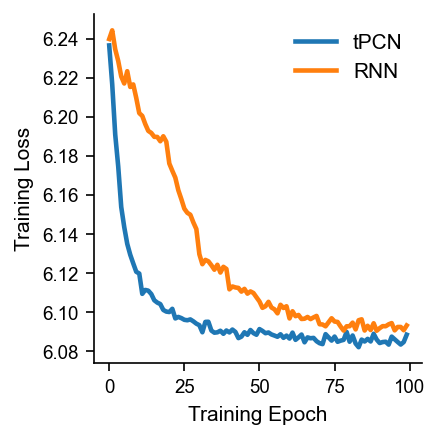

In [4]:
tpc_loss = np.load(os.path.join(tpc_path, 'loss.npy'))
tpc_sparse_loss = np.load(os.path.join(tpc_sparse_path, 'loss.npy'))
rnn_loss = np.load(os.path.join(rnn_path, 'loss.npy'))
rnn_nowd_loss = np.load(os.path.join(rnn_nowd_path, 'loss.npy'))

# Cell-style figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.edgecolor': 'black',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'legend.frameon': False
})

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(tpc_loss, label='tPCN', color='C0', lw=2.2)
ax.plot(rnn_loss, label='RNN', color='C1', lw=2.2)

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

ax.set_xlabel('Training Epoch', fontsize=10)
ax.set_ylabel('Training Loss', fontsize=10)

# Legend styling consistent with Cell figures
ax.legend(loc='upper right', fontsize=10, ncol=1)

# Tidy layout and save
plt.tight_layout()
plt.savefig('../results/learning/loss_cell.pdf', bbox_inches='tight')
plt.show()

In [5]:
# calculate the average grid score across epochs for each model
def calculate_avg_grid_scores(model_path):
    grid_scores = []
    for e in range(0, 102, 2):
        score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
        grid_scores.append(score)
    grid_scores = np.array(grid_scores)  # shape (num_epochs, num_cells)
    avg_grid_scores = np.mean(grid_scores, axis=0)  # shape (num_cells,)
    return avg_grid_scores

tpc_avg_scores = calculate_avg_grid_scores(tpc_path)
rnn_avg_scores = calculate_avg_grid_scores(rnn_path)

In [6]:
tpc_avg_sorted_indices = np.argsort(tpc_avg_scores)
rnn_avg_sorted_indices = np.argsort(rnn_avg_scores)

In [7]:
print(tpc_avg_scores[tpc_avg_sorted_indices[-64:]])
print(rnn_avg_scores[rnn_avg_sorted_indices[-64:]])

[0.7512085  0.75419954 0.76105146 0.76173562 0.76211307 0.76479738
 0.76656382 0.76706601 0.76798728 0.77141528 0.77476069 0.77794816
 0.78425686 0.7891822  0.80284142 0.80296547 0.8055716  0.80704042
 0.80826973 0.81859151 0.82161733 0.8362625  0.84037074 0.84181032
 0.85250802 0.85623504 0.86178456 0.87492071 0.87925418 0.88474122
 0.88515146 0.89145116 0.89217221 0.89238302 0.90384774 0.90568039
 0.91538813 0.92647224 0.9325178  0.93806567 0.94290819 0.94353367
 0.9459588  0.94726367 0.94856776 0.96886471 0.97161705 0.9834489
 0.98496877 0.99446537 0.99590489 0.99623073 0.99796392 0.9994096
 1.00520982 1.00894692 1.01401345 1.01592425 1.05782735 1.06454045
 1.06473918 1.07298037 1.15629361 1.18484064]
[0.63331195 0.63482436 0.63548962 0.63588158 0.63676827 0.64094413
 0.64369762 0.64449155 0.64450295 0.64553344 0.65767109 0.67200995
 0.67216574 0.67923951 0.68123662 0.69796019 0.71476152 0.71701219
 0.71766902 0.72659341 0.7273568  0.727445   0.73003112 0.73091032
 0.74425289 0.7462

In [8]:
# get the cumulative percentage of cells (among those with the highest average scores) that have reached >= 95% of their final grid score
def calculate_cumulative_percentage(model_path, sorted_indices, percent_of_final=0.95, top_k=128):
    num_cells = len(sorted_indices)
    cumulative_percentages = []

    for e in range(0, 102, 2):
        score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
        top_k_indices = sorted_indices[-top_k:]
        count_reached = 0

        for idx in top_k_indices:
            final_score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_100.npy'))[idx]
            if score[idx] >= percent_of_final * final_score:
                count_reached += 1

        cumulative_percentage = (count_reached / top_k) * 100
        cumulative_percentages.append(cumulative_percentage)

    return cumulative_percentages

In [9]:
top_k = 128
tpc_cumu_p_50 = calculate_cumulative_percentage(tpc_path, tpc_avg_sorted_indices, percent_of_final=0.5, top_k=top_k)
tpc_cumu_p_95 = calculate_cumulative_percentage(tpc_path, tpc_avg_sorted_indices, percent_of_final=0.95, top_k=top_k)
rnn_cumu_p_50 = calculate_cumulative_percentage(rnn_path, rnn_avg_sorted_indices, percent_of_final=0.5, top_k=top_k)
rnn_cumu_p_95 = calculate_cumulative_percentage(rnn_path, rnn_avg_sorted_indices, percent_of_final=0.95, top_k=top_k)

In [10]:
tpc_p_50_reaches_50 = next(i for i, v in enumerate(tpc_cumu_p_50) if v >= 50)
tpc_p_95_reaches_50 = next(i for i, v in enumerate(tpc_cumu_p_95) if v >= 50)

diff_tpc = (tpc_p_95_reaches_50 - tpc_p_50_reaches_50) * 2  # multiply by 2 because epochs are every 2 steps

In [11]:
diff_tpc

16

In [12]:
rnn_p_50_reaches_50 = next(i for i, v in enumerate(rnn_cumu_p_50) if v >= 50)
rnn_p_95_reaches_50 = next(i for i, v in enumerate(rnn_cumu_p_95) if v >= 50)

diff_rnn = (rnn_p_95_reaches_50 - rnn_p_50_reaches_50) * 2  # multiply by 2 because epochs are every 2 steps

In [13]:
diff_rnn

38

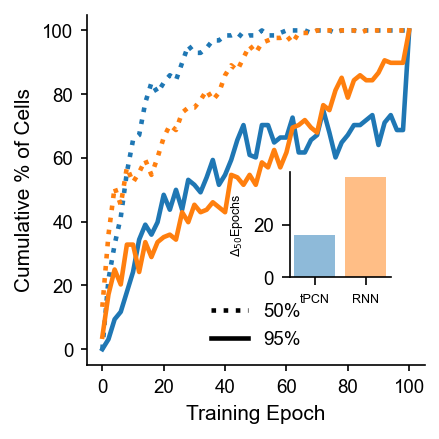

In [14]:
from matplotlib.lines import Line2D
# plot cumulative percentages (Cell-style)
fig, ax = plt.subplots(figsize=(3,3))
x = np.arange(0, 102, 2)

ax.plot(x, tpc_cumu_p_50, label=f'tPCN (50%)', color='C0', lw=2.2, ls=':')
ax.plot(x, tpc_cumu_p_95, label=f'tPCN (95%)', color='C0', lw=2.2)
ax.plot(x, rnn_cumu_p_50, label=f'RNN (50%)', color='C1', lw=2.2, ls=':')
ax.plot(x, rnn_cumu_p_95, label=f'RNN (95%)', color='C1', lw=2.2)

# ax.axhline(50, color='k', lw=0.8, ls='--')

ax.set_xlabel('Training Epoch', fontsize=10)
ax.set_ylabel(f'Cumulative % of Cells', fontsize=10)

# Clean axes to match Cell figure style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.tick_params(length=3, labelsize=9)

# Create custom legend entries with only line styles
legend_elements = [
    Line2D([0], [0], color='k', ls=':', lw=2.2, label='50%'),
    Line2D([0], [0], color='k', lw=2.2, label='95%')
]
ax.legend(handles=legend_elements, frameon=False, ncol=1, fontsize=9, loc=8)

# Add inset axes for bar plot
axins = ax.inset_axes([0.6, 0.25, 0.3, 0.3])
axins.bar([0, 1], [diff_tpc, diff_rnn], color=['C0', 'C1'], alpha=0.5)
axins.set_xticks([0, 1], labels=['tPCN', 'RNN'], fontsize=6)
axins.set_ylabel(r'$\Delta_{50}$Epochs', fontsize=6)
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)
# axins.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../results/learning/cumulative_percent_cell.pdf', bbox_inches='tight')
plt.show()

In [15]:
# for each model and each of the topk cells, get the epoch at which they reach 95% of their final grid score
# then, compute the drift range of the scores after this epoch, defined as the difference between the max and min scores from that epoch to the final epoch
# the function should return a list of drift ranges for the topk cells
def calculate_drift_ranges(model_path, sorted_indices, percent_of_final=0.95, top_k=128):
    drift_ranges = []
    final_scores = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_100.npy'))

    for i in range(-top_k, 0):
        cell_idx = sorted_indices[i]
        final_score = final_scores[cell_idx]

        # find the epoch at which the cell reaches the threshold
        reach_epoch = None
        for e in range(0, 102, 2):
            score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{e}.npy'))[cell_idx]
            if score >= percent_of_final * final_score:
                reach_epoch = e
                break

        if reach_epoch is not None:
            # get scores from reach_epoch to final epoch
            scores_after_reach = []
            for e in range(reach_epoch, 102, 2):
                score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{e}.npy'))[cell_idx]
                scores_after_reach.append(score)
            drift_range = max(scores_after_reach) - min(scores_after_reach)
            drift_ranges.append(drift_range)
        else:
            drift_ranges.append(None)  # did not reach threshold

    return drift_ranges

In [16]:
tpc_drift_ranges = calculate_drift_ranges(tpc_path, tpc_avg_sorted_indices, percent_of_final=0.95, top_k=128)
rnn_drift_ranges = calculate_drift_ranges(rnn_path, rnn_avg_sorted_indices, percent_of_final=0.95, top_k=128)

In [17]:
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
stat, p_value = mannwhitneyu(tpc_drift_ranges, rnn_drift_ranges, alternative='less')
print(f'Mann-Whitney U test p-value: {p_value}')

tpc_arr = np.array([v for v in tpc_drift_ranges if v is not None])
rnn_arr = np.array([v for v in rnn_drift_ranges if v is not None])

t_stat, t_p = ttest_ind(tpc_arr, rnn_arr, equal_var=False, alternative='less')  # Welch's t-test
print(f'Independent-samples t-test (Welch) t-statistic: {t_stat:.4f}, p-value: {t_p:.4g}')

Mann-Whitney U test p-value: 0.030766962507205797
Independent-samples t-test (Welch) t-statistic: -2.3753, p-value: 0.009172


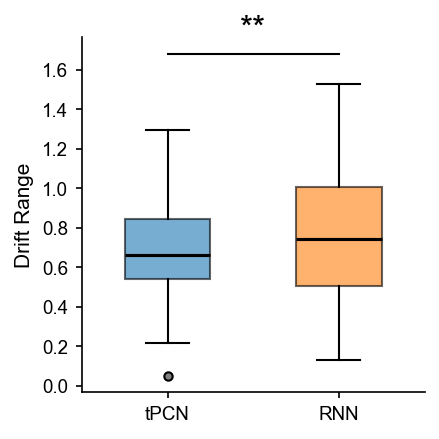

In [19]:
plt.figure(figsize=(3,3))

# Create boxplot with specific colors and style
bp = plt.boxplot([tpc_drift_ranges, rnn_drift_ranges], 
                 labels=['tPCN', 'RNN'],
                 patch_artist=True,
                 medianprops=dict(color='black', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='gray', markersize=4),
                 widths=0.5)

# Set colors for boxes
bp['boxes'][0].set_facecolor('C0')  # tPCN color
bp['boxes'][1].set_facecolor('C1')  # RNN color

# Set alpha for boxes
for box in bp['boxes']:
    box.set_alpha(0.6)

# Clean up the plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tick_params(length=3)

# Add y-label
plt.ylabel('Drift Range', fontsize=10)

# Add significance indicator
# Define significance levels
def get_significance_symbol(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

# Add significance bar and symbol
y_max = max(max(tpc_drift_ranges), max(rnn_drift_ranges))
plt.plot([1, 2], [y_max*1.1, y_max*1.1], 'k-', linewidth=1)
plt.text(1.5, y_max*1.15, get_significance_symbol(t_p), 
         horizontalalignment='center', fontsize=16)

plt.tight_layout()
plt.savefig('../results/learning/drift_range.pdf', bbox_inches='tight')
plt.show()

In [26]:
# sort cells by final grid score and get the indices
final_tpc_scores = np.load(os.path.join(tpc_path, f'grid_scores/grid_scores_epoch_100.npy'))
final_rnn_scores = np.load(os.path.join(rnn_path, f'grid_scores/grid_scores_epoch_100.npy'))
final_tpc_sorted_indices = np.argsort(final_tpc_scores)
final_rnn_sorted_indices = np.argsort(final_rnn_scores)

In [27]:
# in each epoch for each cell among the topk cells sorted by final grid score, fit a linear regression to the final rate map from the current rate map and get the R^2 value
# function should take in model_path, sorted_indices, top_k
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
def calculate_r2_over_time(model_path, sorted_indices, top_k=128):
    r2_over_time = np.zeros((top_k, 51))  # list of lists to hold r2 values for each epoch
    final_epoch = 100

    for i in tqdm(range(-top_k, 0)):
        cell_idx = sorted_indices[i]
        final_rm = np.load(os.path.join(model_path, f'rate_maps_epoch/rate_map_epoch_{final_epoch}.npy'))[cell_idx].flatten().reshape(-1, 1)
        for e in range(0, 102, 2):
            current_rm = np.load(os.path.join(model_path, f'rate_maps_epoch/rate_map_epoch_{e}.npy'))[cell_idx].flatten().reshape(-1, 1)
            model = LinearRegression()
            model.fit(current_rm, final_rm)
            predicted_rm = model.predict(current_rm)
            r2 = r2_score(final_rm, predicted_rm)
            r2_over_time[i][e // 2] = r2

    return r2_over_time

In [28]:
# get the matrix of all grid scores over time for the topk cells
def get_grid_scores_over_time(model_path, sorted_indices, top_k=128):
    grid_scores_over_time = np.zeros((top_k, 51))  # list of lists to hold grid scores for each epoch

    for i in tqdm(range(-top_k, 0)):
        cell_idx = sorted_indices[i]
        for e in range(0, 102, 2):
            score = np.load(os.path.join(model_path, f'grid_scores/grid_scores_epoch_{e}.npy'))[cell_idx]
            grid_scores_over_time[i][e // 2] = score

    return grid_scores_over_time

In [29]:
tpc_score_over_time = get_grid_scores_over_time(tpc_path, final_tpc_sorted_indices, top_k=128)
rnn_score_over_time = get_grid_scores_over_time(rnn_path, final_rnn_sorted_indices, top_k=128)

100%|██████████| 128/128 [00:01<00:00, 127.94it/s]


In [30]:
tpc_r2_over_time = calculate_r2_over_time(tpc_path, final_tpc_sorted_indices, top_k=128)
rnn_r2_over_time = calculate_r2_over_time(rnn_path, final_rnn_sorted_indices, top_k=128)

100%|██████████| 128/128 [00:14<00:00,  8.98it/s]


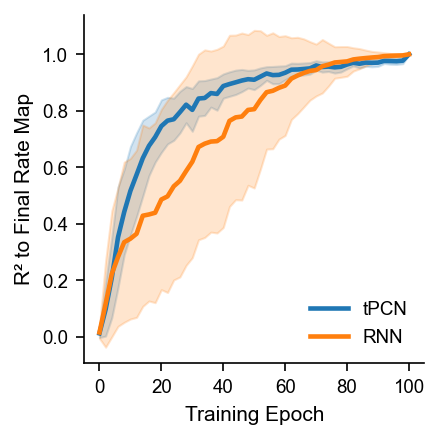

In [83]:
# Cell-style figure settings
tpc_r2_mean = np.mean(tpc_r2_over_time, axis=0)
tpc_r2_std = np.std(tpc_r2_over_time, axis=0)
rnn_r2_mean = np.mean(rnn_r2_over_time, axis=0)
rnn_r2_std = np.std(rnn_r2_over_time, axis=0)
plt.figure(figsize=(3,3))

# Plot means with cleaner style
plt.plot(range(0, 102, 2), tpc_r2_mean, label='tPCN', color='C0', lw=2.2)
plt.fill_between(range(0, 102, 2), tpc_r2_mean - tpc_r2_std, tpc_r2_mean + tpc_r2_std, 
                 color='C0', alpha=0.2)

plt.plot(range(0, 102, 2), rnn_r2_mean, label='RNN', color='C1', lw=2.2)
plt.fill_between(range(0, 102, 2), rnn_r2_mean - rnn_r2_std, rnn_r2_mean + rnn_r2_std, 
                 color='C1', alpha=0.2)

# Clean axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(False)

# Labels
plt.xlabel('Training Epoch', fontsize=10)
plt.ylabel('R² to Final Rate Map', fontsize=10)

# Legend styling consistent with Cell figures
plt.legend(loc='lower right', fontsize=9, ncol=1, frameon=False)

# Tidy layout and save
plt.tight_layout()
plt.savefig('../results/learning/r2_evolution_cell.pdf', bbox_inches='tight')
plt.show()

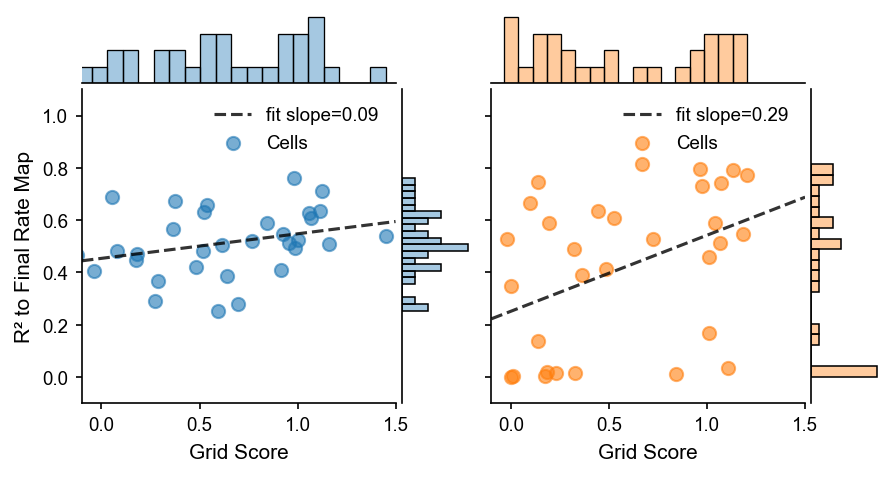

In [134]:
def plot_grid_score_vs_r2_subplots(epoch, tpc_scores_over_time, tpc_r2_over_time,
                                  rnn_scores_over_time, rnn_r2_over_time, top_k=128):
    epoch_idx = epoch // 2
    tpc_scores = tpc_scores_over_time[-top_k:, epoch_idx]
    tpc_r2 = tpc_r2_over_time[-top_k:, epoch_idx]
    rnn_scores = rnn_scores_over_time[-top_k:, epoch_idx]
    rnn_r2 = rnn_r2_over_time[-top_k:, epoch_idx]

    # make room for marginal plots and keep each subplot visually square
    fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)
    plt.subplots_adjust(wspace=0.35, top=0.88, right=0.88)

    for ax, scores, r2_values, color, label in [
        (axes[0], tpc_scores, tpc_r2, 'C0', 'tPCN'),
        (axes[1], rnn_scores, rnn_r2, 'C1', 'RNN'),
    ]:
        X = scores.reshape(-1, 1)
        y = r2_values.reshape(-1, 1)
        model = LinearRegression()
        model.fit(X, y)
        slope = float(model.coef_.ravel()[0])
        intercept = float(model.intercept_.ravel()[0])

        # regression line over plotting range
        x_min, x_max = -0.1, 1.5
        x_line = np.linspace(x_min, x_max, 200)
        y_line = model.predict(x_line.reshape(-1, 1)).ravel()

        ax.plot(x_line, y_line, color='k', linestyle='--', alpha=0.8,
                label=f'fit slope={slope:.2f}')
        ax.scatter(scores, r2_values, alpha=0.6, color=color, s=40, label='Cells')
        ax.set_xlabel('Grid Score', fontsize=10)
        if label == 'tPCN':
            ax.set_ylabel('R² to Final Rate Map', fontsize=10)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.1, 1.1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(length=3)
        ax.legend(frameon=False, fontsize=9)

        # force the axis box to be square (visual square, not equal data scaling)
        try:
            ax.set_box_aspect(1)
        except Exception:
            # fallback for older matplotlib: adjust aspect (may change data scaling)
            ax.set_aspect('equal', adjustable='box')

        # add marginal hist + kde for x (top) and y (right)
        # place marginal axes just outside the main axes — margins above/right were increased
        ax_x = ax.inset_axes([0, 1.02, 1, 0.22])   # top histogram
        ax_y = ax.inset_axes([1.02, 0, 0.22, 1])   # right histogram

        # X marginal (hist + kde)
        try:
            sns.histplot(scores, bins=20, stat='density', color=color, alpha=0.4, ax=ax_x)
            # sns.kdeplot(scores, bw_method='scott', color=color, lw=1.2, ax=ax_x)
        except Exception:
            ax_x.hist(scores, bins=20, density=True, color=color, alpha=0.4)
        ax_x.set_xlim(x_min, x_max)
        ax_x.set_yticks([])
        ax_x.set_xticks([])
        ax_x.spines['top'].set_visible(False)
        ax_x.spines['right'].set_visible(False)
        ax_x.spines['left'].set_visible(False)
        ax_x.tick_params(axis='x', labelsize=7)
        ax_x.set_xlabel('')  # keep it clean
        ax_x.set_ylabel('')

        # Y marginal (horizontal hist + kde)
        try:
            sns.histplot(y=r2_values, bins=20, stat='density', color=color, alpha=0.4,
                         ax=ax_y, orientation='vertical')
            # sns.kdeplot(y=r2_values, bw_method='scott', color=color, lw=1.2, ax=ax_y)
        except Exception:
            ax_y.hist(y=r2_values, bins=20, density=True, orientation='vertical',
                      color=color, alpha=0.4)
        ax_y.set_ylim(-0.1, 1.1)
        ax_y.set_xticks([])
        ax_y.set_yticks([])
        ax_y.spines['top'].set_visible(False)
        ax_y.spines['right'].set_visible(False)
        ax_y.spines['bottom'].set_visible(False)
        ax_y.tick_params(axis='y', labelsize=7)
        ax_y.set_ylabel('')  # keep it clean
        ax_y.set_xlabel('')

    plt.tight_layout()
    plt.savefig(f'../results/learning/grid_score_vs_r2_epoch_{epoch}_cell.pdf', bbox_inches='tight')
    plt.show()

# call for epoch 10 and top_k=32 for both models
plot_grid_score_vs_r2_subplots(10, tpc_score_over_time, tpc_r2_over_time,
                              rnn_score_over_time, rnn_r2_over_time, top_k=32)

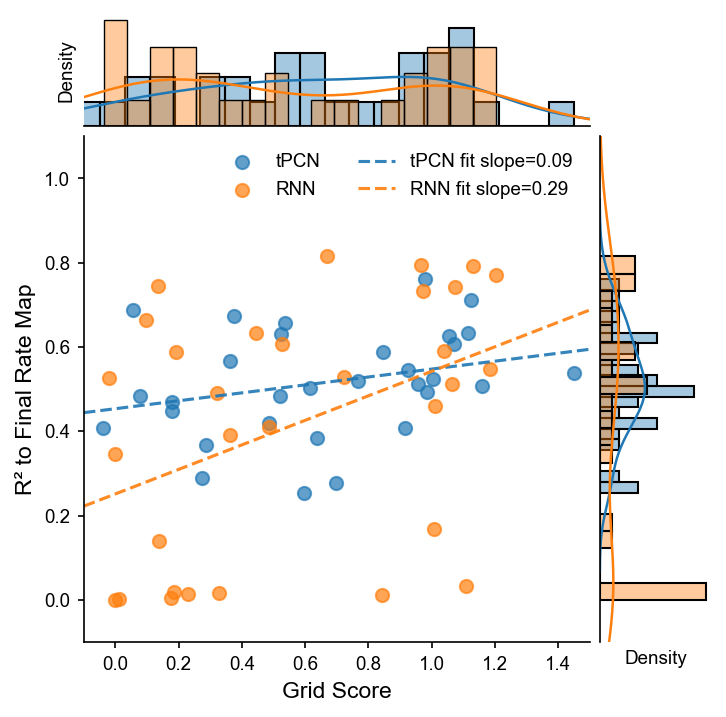

In [132]:
def plot_combined_scatter_with_marginals(epoch, tpc_scores_over_time, tpc_r2_over_time,
                                         rnn_scores_over_time, rnn_r2_over_time, top_k=128):
    epoch_idx = epoch // 2
    tpc_scores = tpc_scores_over_time[-top_k:, epoch_idx]
    tpc_r2 = tpc_r2_over_time[-top_k:, epoch_idx]
    rnn_scores = rnn_scores_over_time[-top_k:, epoch_idx]
    rnn_r2 = rnn_r2_over_time[-top_k:, epoch_idx]

    fig, ax = plt.subplots(figsize=(5, 5))

    # plotting range
    x_min, x_max = -0.1, 1.5
    y_min, y_max = -0.1, 1.1

    # scatter points
    ax.scatter(tpc_scores, tpc_r2, alpha=0.7, color='C0', s=40, label='tPCN')
    ax.scatter(rnn_scores, rnn_r2, alpha=0.7, color='C1', s=40, label='RNN')

    # fit separate linear regressions and plot dashed lines
    for scores, r2_vals, color, lbl in [
        (tpc_scores, tpc_r2, 'C0', 'tPCN fit'),
        (rnn_scores, rnn_r2, 'C1', 'RNN fit'),
    ]:
        X = scores.reshape(-1, 1)
        y = r2_vals.reshape(-1, 1)
        try:
            model = LinearRegression()
            model.fit(X, y)
            x_line = np.linspace(x_min, x_max, 200).reshape(-1, 1)
            y_line = model.predict(x_line).ravel()
            ax.plot(x_line.ravel(), y_line, color=color, linestyle='--', alpha=0.9,
                    label=f'{lbl} slope={float(model.coef_.ravel()[0]):.2f}')
        except Exception:
            pass

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Grid Score', fontsize=11)
    ax.set_ylabel('R² to Final Rate Map', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(length=3)
    ax.legend(frameon=False, fontsize=9, ncol=2)

    # Marginal axes: top (x) and right (y)
    ax_x = ax.inset_axes([0, 1.02, 1, 0.22])   # top marginal
    ax_y = ax.inset_axes([1.02, 0, 0.22, 1])   # right marginal

    # X marginal: hist + kde for both models
    try:
        sns.histplot(tpc_scores, bins=20, stat='density', color='C0', alpha=0.4, ax=ax_x, label='tPCN')
        sns.kdeplot(tpc_scores, bw_method='scott', color='C0', lw=1.2, ax=ax_x)
        sns.histplot(rnn_scores, bins=20, stat='density', color='C1', alpha=0.4, ax=ax_x, label='RNN')
        sns.kdeplot(rnn_scores, bw_method='scott', color='C1', lw=1.2, ax=ax_x)
    except Exception:
        ax_x.hist(tpc_scores, bins=20, density=True, color='C0', alpha=0.4)
        ax_x.hist(rnn_scores, bins=20, density=True, color='C1', alpha=0.4)
    ax_x.set_xlim(x_min, x_max)
    ax_x.set_yticks([])
    ax_x.set_xticks([])
    ax_x.spines['top'].set_visible(False)
    ax_x.spines['right'].set_visible(False)
    ax_x.spines['left'].set_visible(False)

    # Y marginal: horizontal hist + kde for both models
    try:
        sns.histplot(y=tpc_r2, bins=20, stat='density', color='C0', alpha=0.4, ax=ax_y, orientation='vertical')
        sns.kdeplot(y=tpc_r2, bw_method='scott', color='C0', lw=1.2, ax=ax_y)
        sns.histplot(y=rnn_r2, bins=20, stat='density', color='C1', alpha=0.4, ax=ax_y, orientation='vertical')
        sns.kdeplot(y=rnn_r2, bw_method='scott', color='C1', lw=1.2, ax=ax_y)
    except Exception:
        ax_y.hist(tpc_r2, bins=20, density=True, color='C0', alpha=0.4, orientation='horizontal')
        ax_y.hist(rnn_r2, bins=20, density=True, color='C1', alpha=0.4, orientation='horizontal')
    ax_y.set_ylim(y_min, y_max)
    ax_y.set_xticks([])
    ax_y.set_yticks([])
    ax_y.spines['top'].set_visible(False)
    ax_y.spines['right'].set_visible(False)
    ax_y.spines['bottom'].set_visible(False)

    # Make main axis visually square if supported
    try:
        ax.set_box_aspect(1)
    except Exception:
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

# Example call: epoch 10, show top 32 cells from each model
plot_combined_scatter_with_marginals(10, tpc_score_over_time, tpc_r2_over_time,
                                     rnn_score_over_time, rnn_r2_over_time, top_k=32)

In [24]:
# plot ratemaps of top 32 cells by final grid score for both models at epoch 20, 100
# for each model, get 4x8 subplots with subplot title indicating cell index, grid score, r2 value
def plot_ratemaps_at_epoch(model_path, sorted_indices, scores_over_time, r2_over_time, epoch, top_k=32):
    epoch_idx = epoch // 2
    plt.figure(figsize=(12,6))
    
    for i in range(-top_k, 0):
        cell_idx = sorted_indices[i]
        rm = np.load(os.path.join(model_path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))[cell_idx]
        score = scores_over_time[i][epoch_idx]
        r2 = r2_over_time[i][epoch_idx]
        
        plt.subplot(4, 8, i + top_k + 1)
        plt.imshow(rm, cmap='viridis')
        plt.title(f'Cell {cell_idx}\nScore: {score:.2f}, R²: {r2:.2f}', fontsize=8)
        plt.axis('off')
    
    plt.suptitle(f'Ratemaps at Epoch {epoch} (Top {top_k} Cells)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# do the same for sac
def plot_sacs_at_epoch(model_path, sorted_indices, scores_over_time, r2_over_time, epoch, top_k=32):
    epoch_idx = epoch // 2
    plt.figure(figsize=(12,6))
    
    for i in range(-top_k, 0):
        cell_idx = sorted_indices[i]
        sac = np.load(os.path.join(model_path, f'sacs/sacs_epoch_{epoch}.npy'))[cell_idx]
        score = scores_over_time[i][epoch_idx]
        r2 = r2_over_time[i][epoch_idx]
        
        plt.subplot(4, 8, i + top_k + 1)
        plt.imshow(sac, cmap='viridis')
        plt.title(f'Cell {cell_idx}\nScore: {score:.2f}, R²: {r2:.2f}', fontsize=8)
        plt.axis('off')
    
    plt.suptitle(f'Spatial Autocorrelations at Epoch {epoch} (Top {top_k} Cells)', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

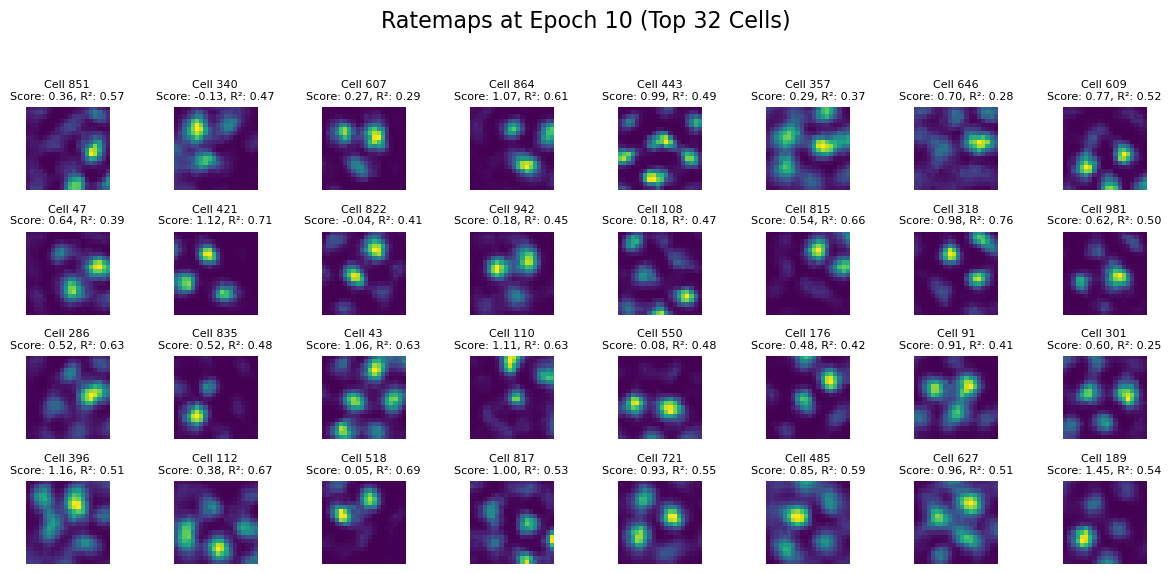

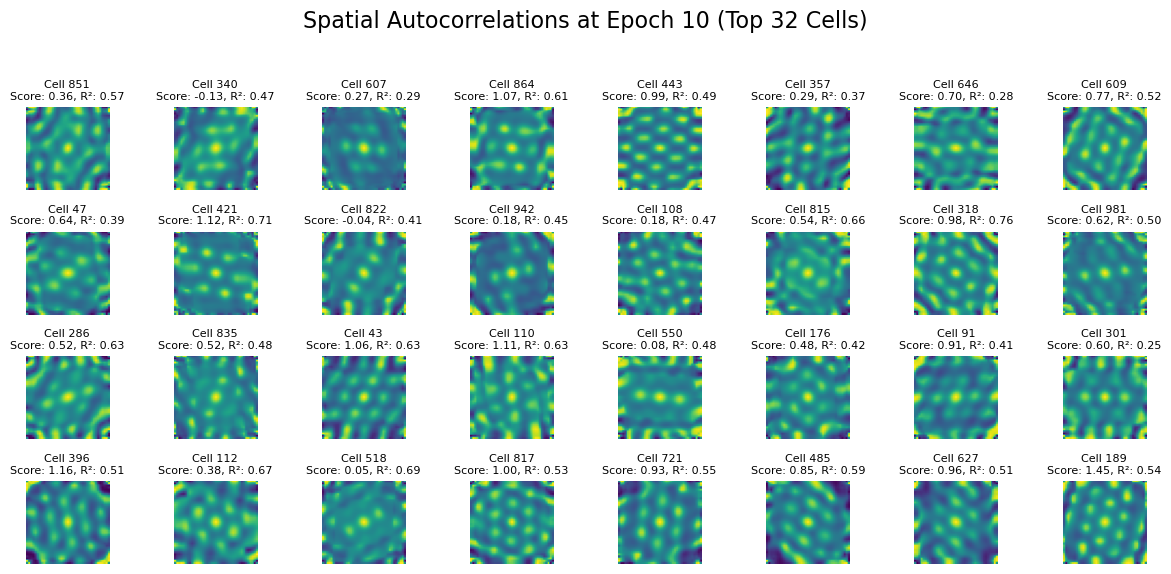

In [49]:
plot_ratemaps_at_epoch(tpc_path, final_tpc_sorted_indices, tpc_score_over_time, tpc_r2_over_time, epoch=10, top_k=32)
plot_sacs_at_epoch(tpc_path, final_tpc_sorted_indices, tpc_score_over_time, tpc_r2_over_time, epoch=10, top_k=32)

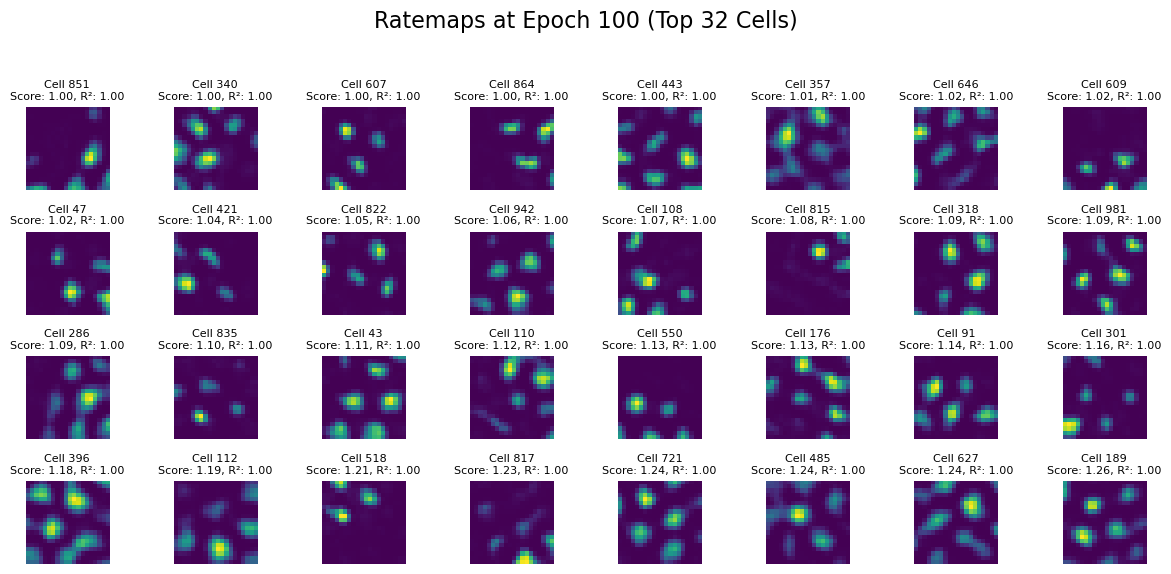

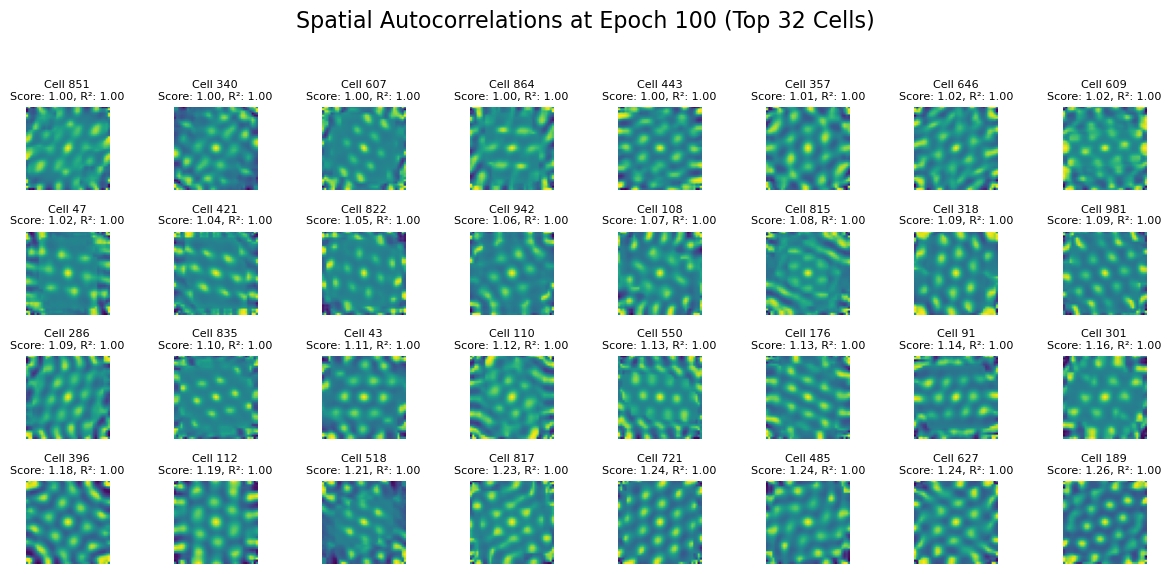

In [29]:
plot_ratemaps_at_epoch(tpc_path, final_tpc_sorted_indices, tpc_score_over_time, tpc_r2_over_time, epoch=100, top_k=32)
plot_sacs_at_epoch(tpc_path, final_tpc_sorted_indices, tpc_score_over_time, tpc_r2_over_time, epoch=100, top_k=32)

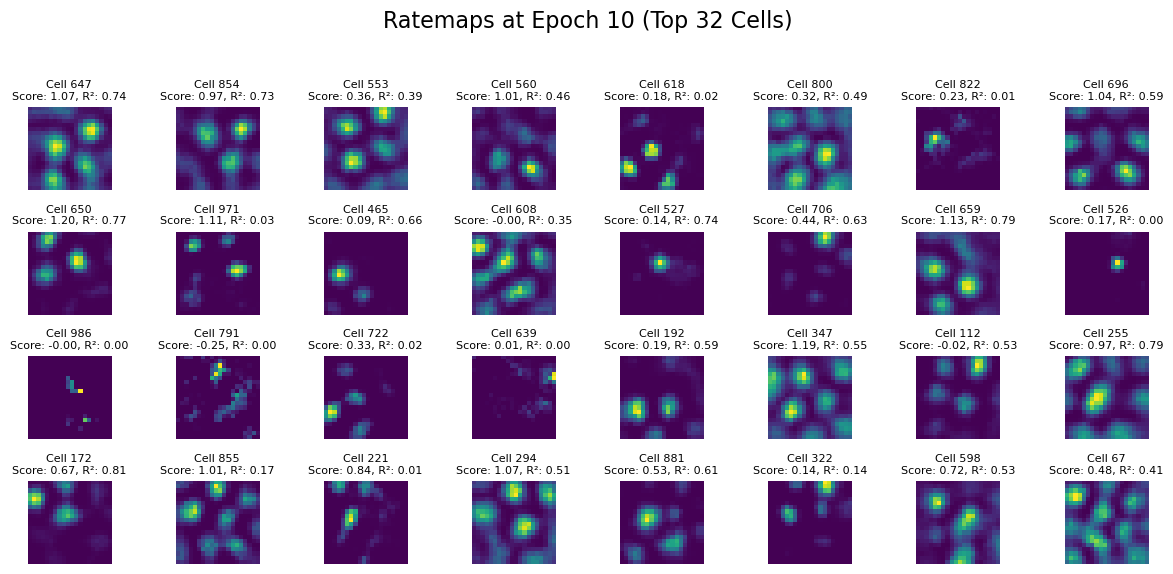

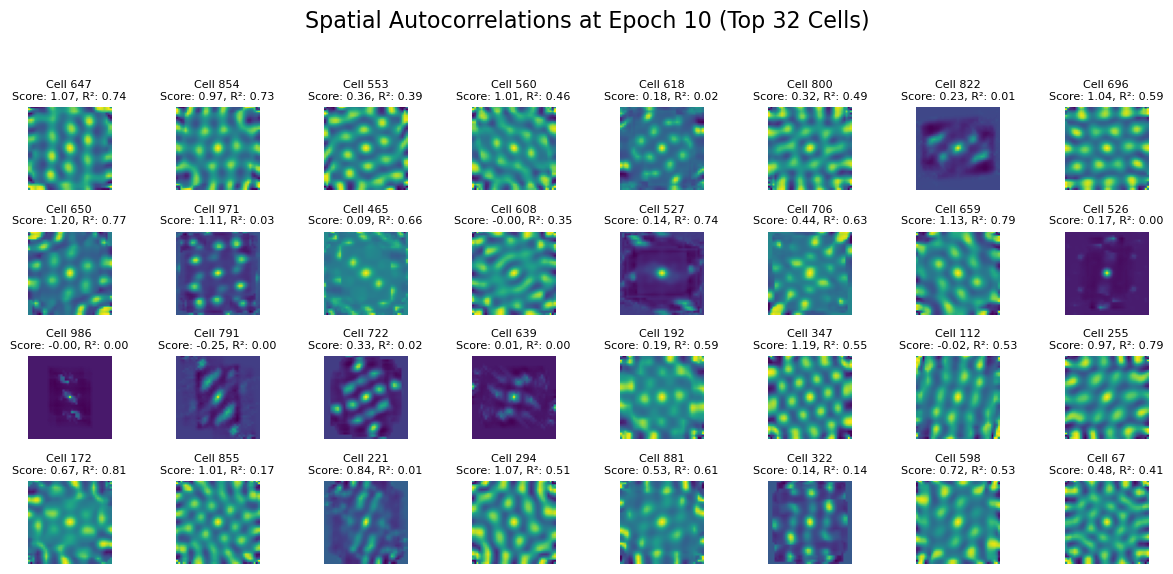

In [30]:
plot_ratemaps_at_epoch(rnn_path, final_rnn_sorted_indices, rnn_score_over_time, rnn_r2_over_time, epoch=10, top_k=32)
plot_sacs_at_epoch(rnn_path, final_rnn_sorted_indices, rnn_score_over_time, rnn_r2_over_time, epoch=10, top_k=32)

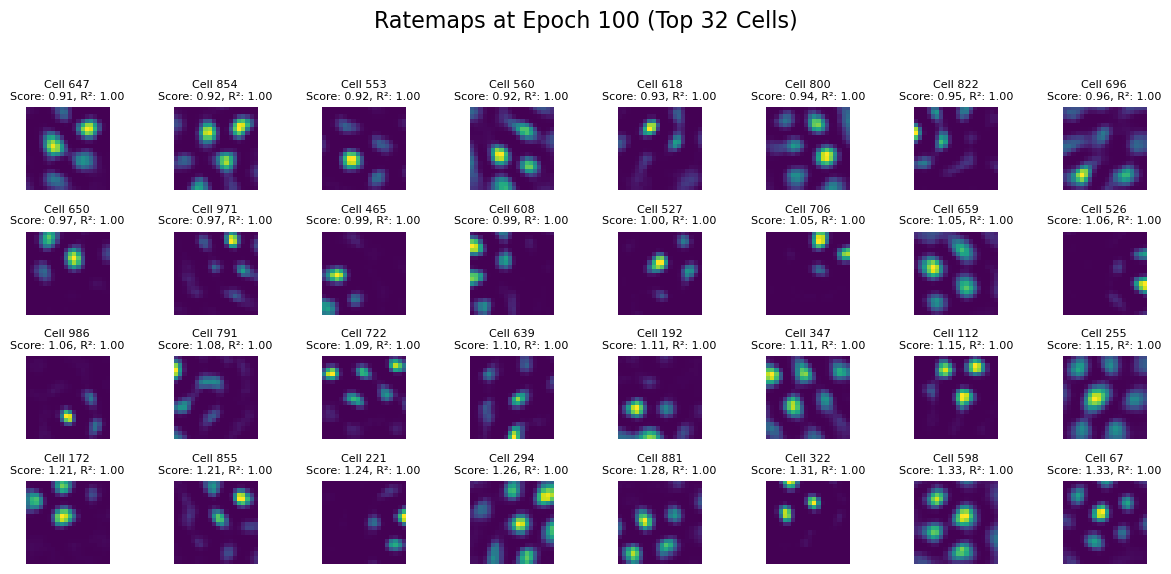

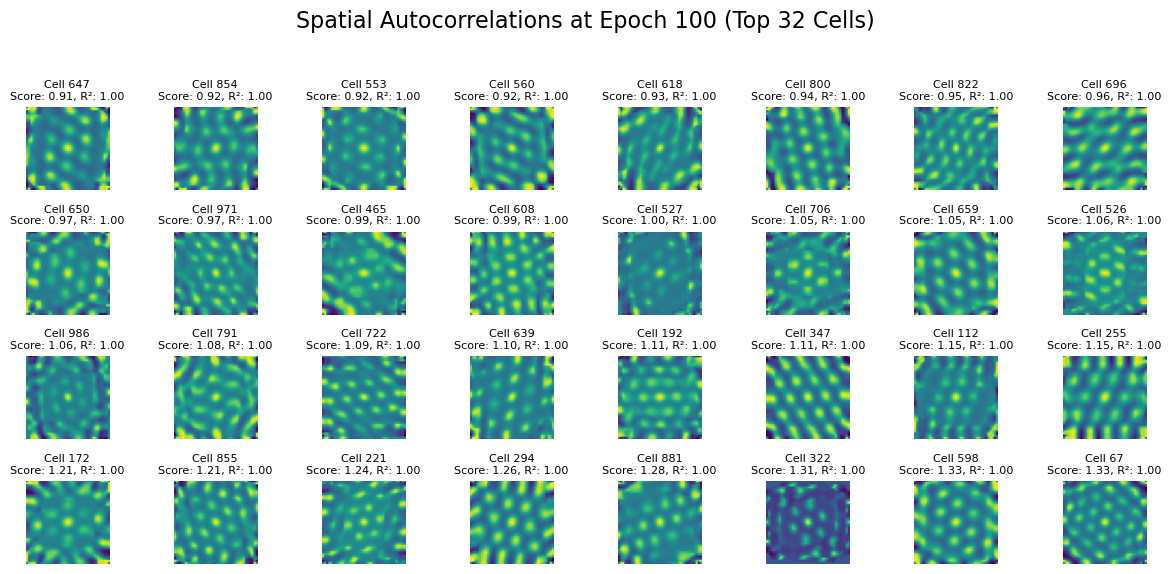

In [31]:
plot_ratemaps_at_epoch(rnn_path, final_rnn_sorted_indices, rnn_score_over_time, rnn_r2_over_time, epoch=100, top_k=32)
plot_sacs_at_epoch(rnn_path, final_rnn_sorted_indices, rnn_score_over_time, rnn_r2_over_time, epoch=100, top_k=32)

In [98]:
# plot single cell's rm and sac at a particular epoch
def plot_single_cell_rm_sac(model_path, sorted_indices, top_k, scores_over_time, r2_over_time, cell_idx, epoch):
    rm = np.load(os.path.join(model_path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))[cell_idx]
    rm = (rm - np.min(rm)) / (np.max(rm) - np.min(rm))  # normalize for better visualization
    sac = np.load(os.path.join(model_path, f'sacs/sacs_epoch_{epoch}.npy'))[cell_idx]
    i = np.where(sorted_indices[-top_k:] == cell_idx)[0][0]  # get index in sorted list
    score = scores_over_time[i][epoch//2]
    r2 = r2_over_time[i][epoch//2]

    plt.figure(figsize=(3,2))
    
    plt.subplot(1, 2, 1)
    plt.imshow(rm, cmap='jet', interpolation='bilinear')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(sac, cmap='jet', interpolation='bilinear')
    plt.axis('off')

    # plot suptitle with cell index, epoch, grid score, r2 value
    plt.suptitle(f'Score: {score:.2f}, R²: {r2:.2f}', fontsize=18)
    
    plt.tight_layout()
    plt.savefig(f'../results/learning/single_cell_rm_sac_epoch_{epoch}_cell_{cell_idx}.pdf', bbox_inches='tight')
    plt.show()

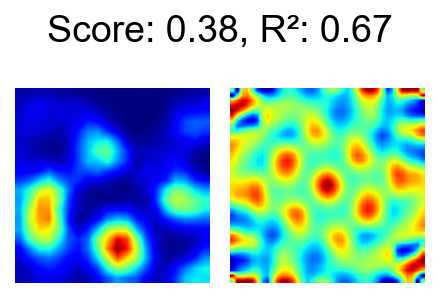

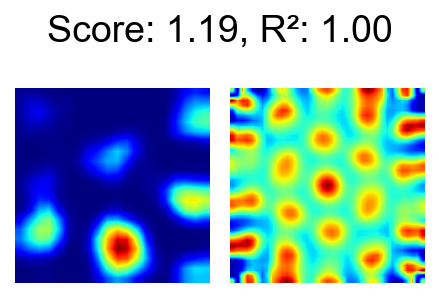

In [99]:
plot_single_cell_rm_sac(tpc_path, final_tpc_sorted_indices, 128, tpc_score_over_time, tpc_r2_over_time, cell_idx=112, epoch=10)
plot_single_cell_rm_sac(tpc_path, final_tpc_sorted_indices, 128, tpc_score_over_time, tpc_r2_over_time, cell_idx=112, epoch=100)

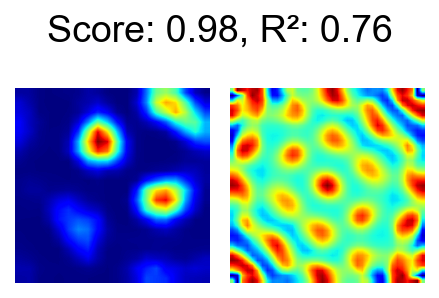

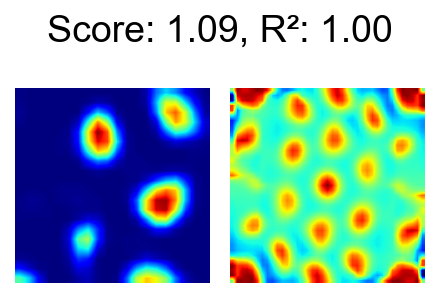

In [100]:
plot_single_cell_rm_sac(tpc_path, final_tpc_sorted_indices, 128, tpc_score_over_time, tpc_r2_over_time, cell_idx=318, epoch=10)
plot_single_cell_rm_sac(tpc_path, final_tpc_sorted_indices, 128, tpc_score_over_time, tpc_r2_over_time, cell_idx=318, epoch=100)

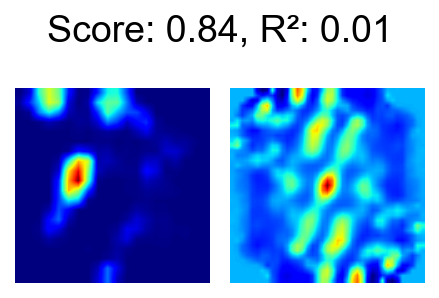

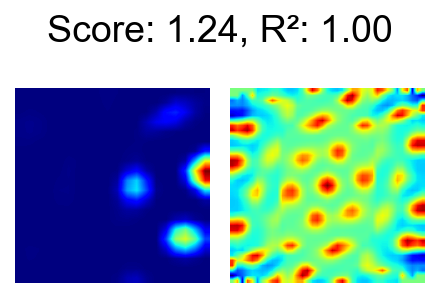

In [137]:
plot_single_cell_rm_sac(rnn_path, final_rnn_sorted_indices, 128, rnn_score_over_time, rnn_r2_over_time, cell_idx=221, epoch=10)
plot_single_cell_rm_sac(rnn_path, final_rnn_sorted_indices, 128, rnn_score_over_time, rnn_r2_over_time, cell_idx=221, epoch=100)

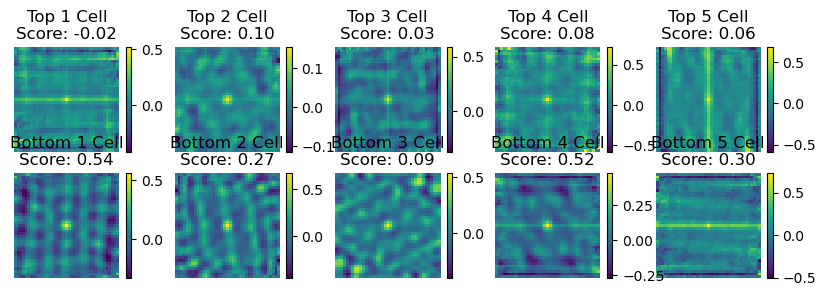

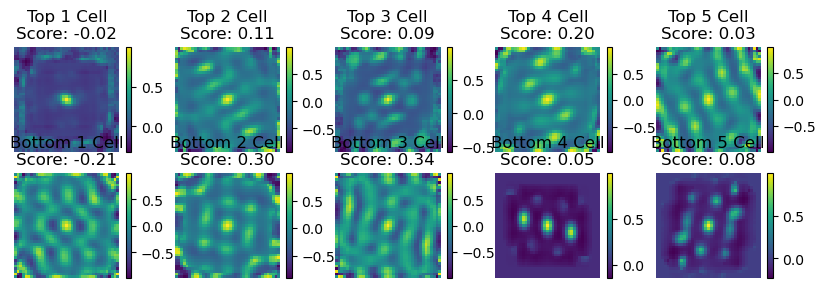

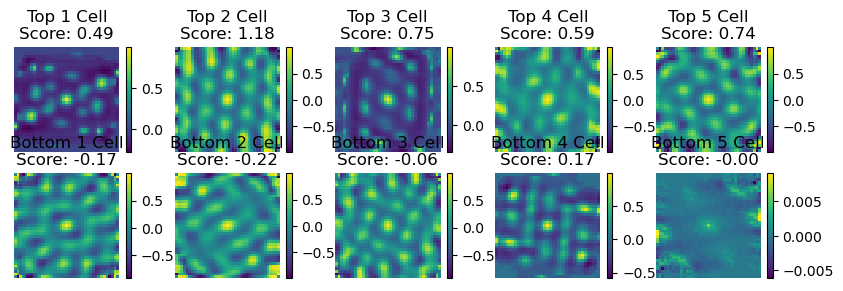

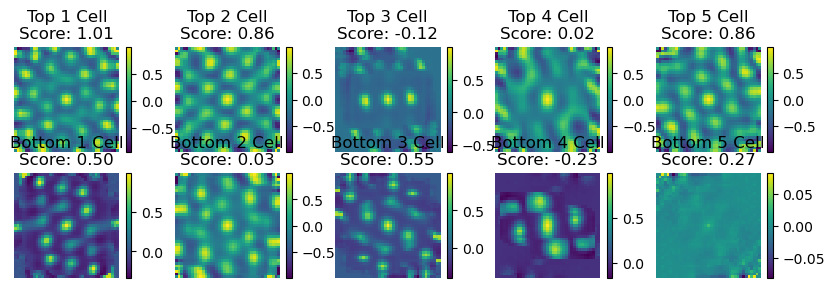

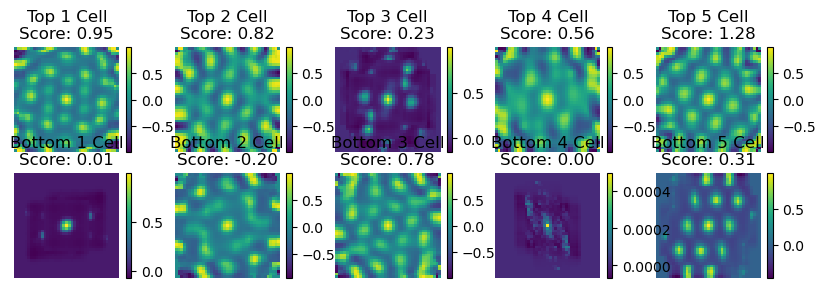

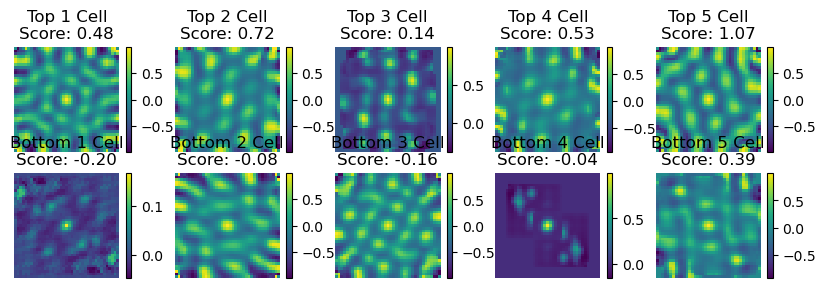

In [12]:
final_sorted_indices = np.argsort(np.load(os.path.join(rnn_path, 'grid_scores/grid_scores_epoch_100.npy')))
for e in range(0, 12, 2):
    sac = np.load(os.path.join(rnn_path, f'sacs/sacs_epoch_{e}.npy'))
    score = np.load(os.path.join(rnn_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
    # sort scores and then use the indices to sort sacs
    sac_sorted = sac[final_sorted_indices]
    score_sorted = score[final_sorted_indices]
    
    # for each epoch, plot the sac heatmap for top 5 cells and bottom 5 cells (one cell per subplot)
    fig, axs =plt.subplots(2, 5, figsize=(10, 3))
    for i in range(5):
        im_top = axs[0, i].imshow(sac_sorted[-(i+1)], interpolation='nearest')
        axs[0, i].set_title(f'Top {i+1} Cell\nScore: {score_sorted[-(i+1)]:.2f}')
        axs[0, i].axis('off')
        fig.colorbar(im_top, ax=axs[0, i])
        
        im_bottom = axs[1, i].imshow(sac_sorted[i], interpolation='nearest')
        axs[1, i].set_title(f'Bottom {i+1} Cell\nScore: {score_sorted[i]:.2f}')
        axs[1, i].axis('off')
        fig.colorbar(im_bottom, ax=axs[1, i])

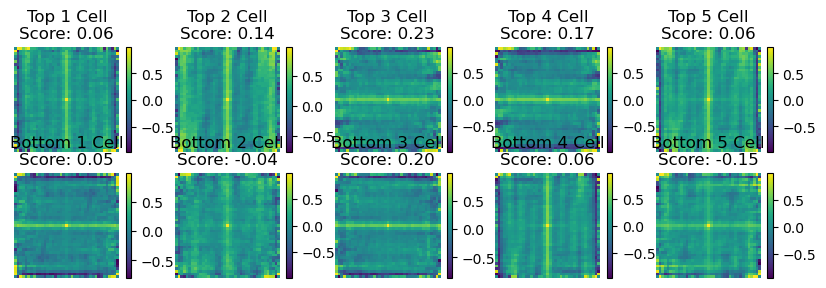

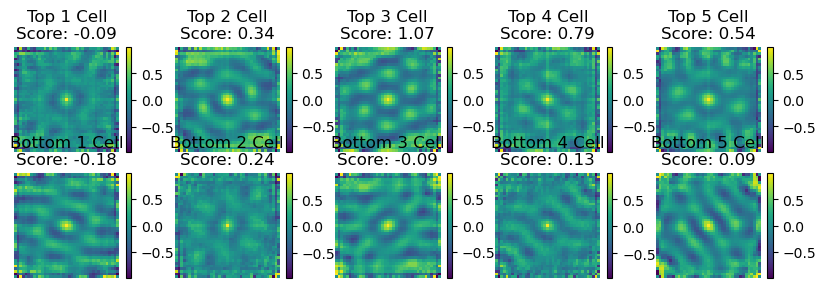

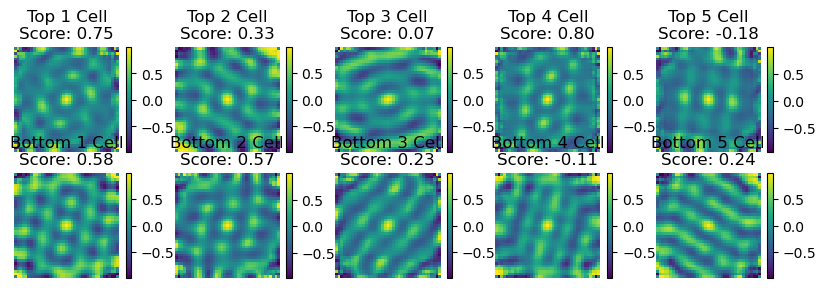

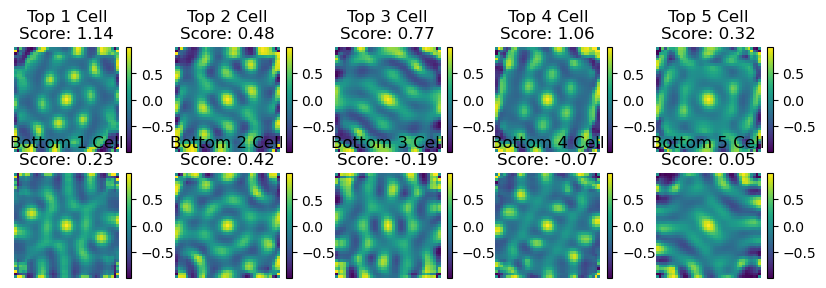

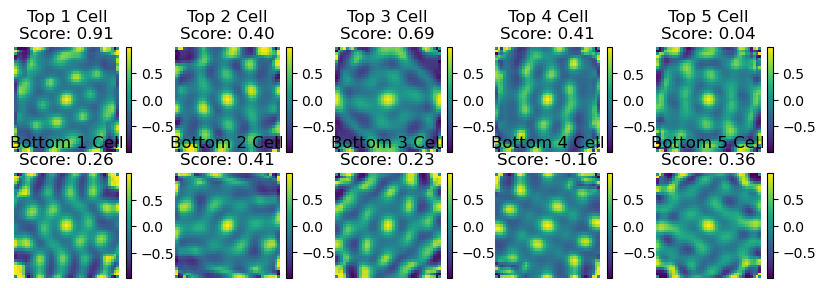

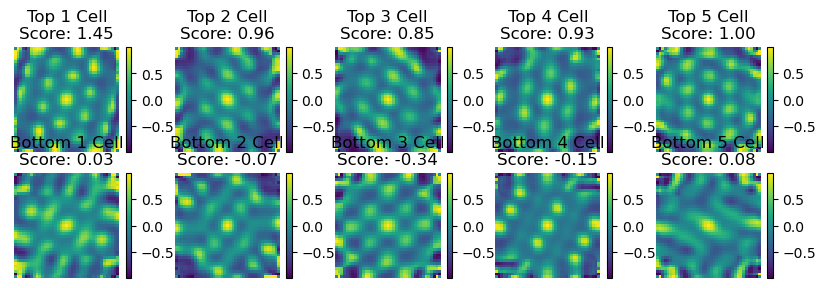

In [11]:
final_sorted_indices = np.argsort(np.load(os.path.join(tpc_path, 'grid_scores/grid_scores_epoch_100.npy')))
for e in range(0, 12, 2):
    sac = np.load(os.path.join(tpc_path, f'sacs/sacs_epoch_{e}.npy'))
    score = np.load(os.path.join(tpc_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
    # sort scores and then use the indices to sort sacs
    sac_sorted = sac[final_sorted_indices]
    score_sorted = score[final_sorted_indices]
    
    # for each epoch, plot the sac heatmap for top 5 cells and bottom 5 cells (one cell per subplot)
    fig, axs =plt.subplots(2, 5, figsize=(10, 3))
    for i in range(5):
        im_top = axs[0, i].imshow(sac_sorted[-(i+1)], interpolation='nearest')
        axs[0, i].set_title(f'Top {i+1} Cell\nScore: {score_sorted[-(i+1)]:.2f}')
        axs[0, i].axis('off')
        fig.colorbar(im_top, ax=axs[0, i])
        
        im_bottom = axs[1, i].imshow(sac_sorted[i], interpolation='nearest')
        axs[1, i].set_title(f'Bottom {i+1} Cell\nScore: {score_sorted[i]:.2f}')
        axs[1, i].axis('off')
        fig.colorbar(im_bottom, ax=axs[1, i])

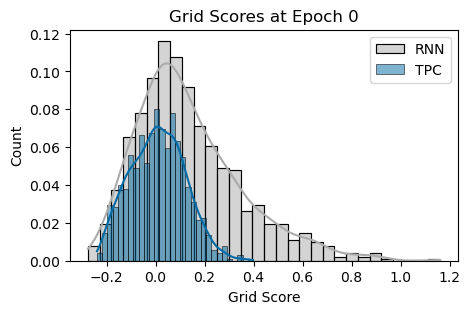

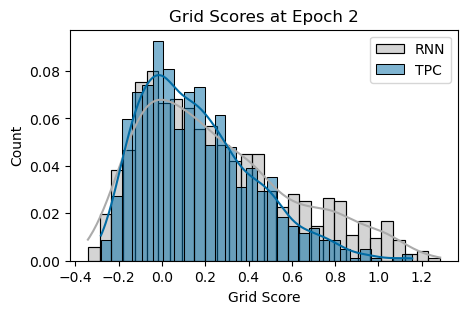

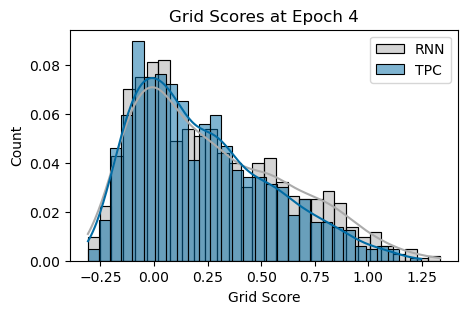

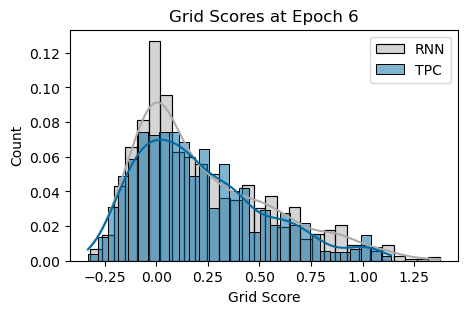

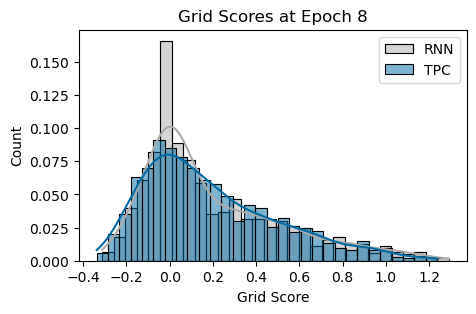

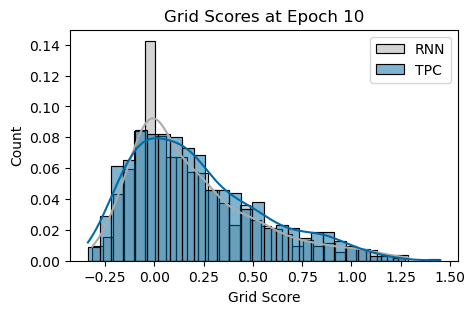

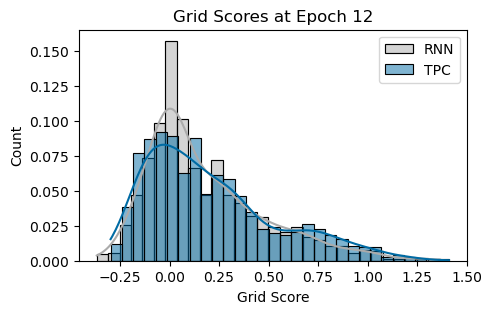

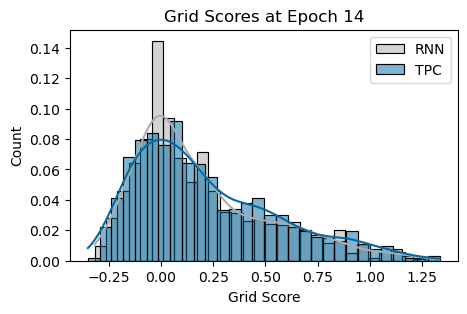

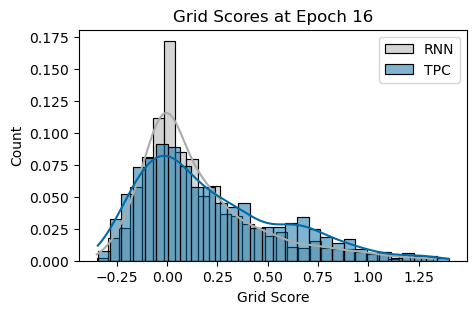

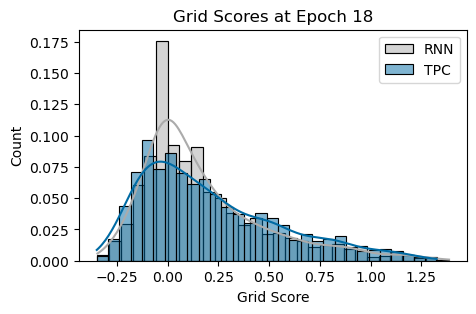

In [17]:
# compare distribution of grid scores at different epochs
for e in range(0, 20, 2):
    rnn_score = np.load(os.path.join(rnn_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
    tpc_score = np.load(os.path.join(tpc_path, f'grid_scores/grid_scores_epoch_{e}.npy'))
    plt.figure(figsize=(5,3))
    sns.histplot(rnn_score, bins=30, kde=True, color='C2', stat='probability', alpha=0.5, label='RNN')
    sns.histplot(tpc_score, bins=30, kde=True, color='C0', stat='probability', alpha=0.5, label='TPC')
    plt.title(f'Grid Scores at Epoch {e}')
    plt.xlabel('Grid Score')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

In [4]:
# load model weights from path/models/epoch_{i}.pth

def load_model(path, epoch):
    model_path = os.path.join(path, 'models', f'epoch_{epoch}.pth')
    weights = torch.load(model_path)
    return weights

tpc_weights = load_model(tpc_path, 100)

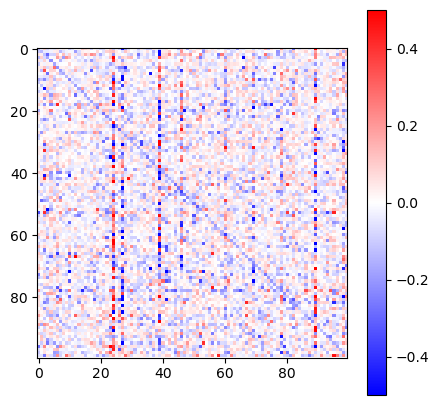

In [33]:
tpc_weights = load_model(tpc_path, 80)
Wr = tpc_weights['model']['Wr.weight']
# visualize recurrent weights between the first 100 neurons
plt.figure(figsize=(5,5))
plt.imshow(Wr.cpu().numpy()[:100,:100], cmap='bwr', vmin=-0.5, vmax=0.5)
plt.colorbar()
plt.show()

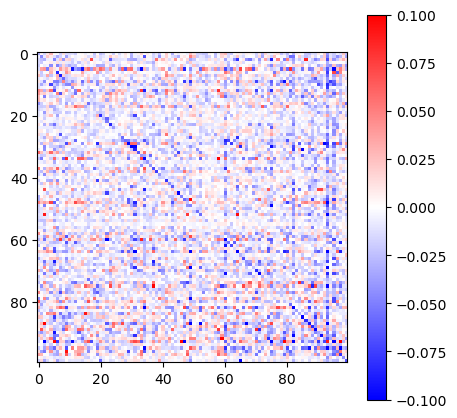

In [36]:
# rnn weights
rnn_weights = load_model(rnn_path, 2)
Wr_rnn = rnn_weights['RNN.weight_hh_l0']
plt.figure(figsize=(5,5))
plt.imshow(Wr_rnn.cpu().numpy()[:100,:100], cmap='bwr', vmin=-0.1, vmax=0.1)
plt.colorbar()
plt.show()

In [58]:
# initialize a tpc model to compare initial weights
class Options:
    pass
options = Options()

# load configs into options
with open(os.path.join(tpc_path, 'configs.json'), 'r') as f:
    config = json.load(f)
for key, value in config.items():
    setattr(options, key, value)
tpc = TemporalPCN(options)
initial_Wrtpc = tpc.Wr.weight.detach().cpu().numpy()
initial_Wrtpc_magnitude = np.linalg.norm(initial_Wr)

In [59]:
# initial rnn weights
with open(os.path.join(rnn_path, 'configs.json'), 'r') as f:
    config = json.load(f)
for key, value in config.items():
    setattr(options, key, value)

place_cells = PlaceCells(options)
rnn = RNN(options, place_cells)
initial_Wrnn = rnn.RNN.weight_hh_l0.detach().cpu().numpy()
initial_Wrnn_magnitude = np.linalg.norm(initial_Wrnn)

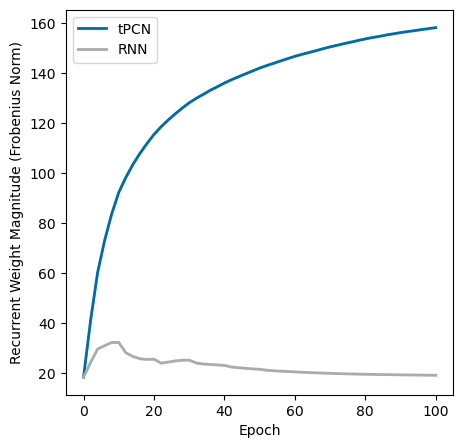

In [ ]:
# compare the magnitude evolution of recurrent weights in tPCN and RNN
# epochs from 2 to 100, skip by 2
tpc_Wr_evolution = [initial_Wrtpc]
rnn_Wr_evolution = [initial_Wrnn]
for epoch in range(2, 101, 2):
    tpc_weights = load_model(tpc_path, epoch)
    Wr = tpc_weights['model']['Wr.weight']
    tpc_Wr_evolution.append(Wr.cpu().numpy().copy())
    
    rnn_weights = load_model(rnn_path, epoch)
    Wr_rnn = rnn_weights['RNN.weight_hh_l0']
    rnn_Wr_evolution.append(Wr_rnn.cpu().numpy().copy())
    
tpc_Wr_evolution = np.array(tpc_Wr_evolution)  # shape (epochs, N, N)
rnn_Wr_evolution = np.array(rnn_Wr_evolution)  # shape (epochs, N, N)
tpc_Wr_magnitude = np.linalg.norm(tpc_Wr_evolution, axis=(1,2))
rnn_Wr_magnitude = np.linalg.norm(rnn_Wr_evolution, axis=(1,2))
plt.figure(figsize=(5,5))
plt.plot(tpc_Wr_magnitude, label='tPCN', color='C0', lw=2)
plt.plot(rnn_Wr_magnitude, label='RNN', color='C2', lw=2)
plt.xlabel('Epoch')
plt.ylabel('Recurrent Weight Magnitude (Frobenius Norm)')
plt.legend()
plt.show()

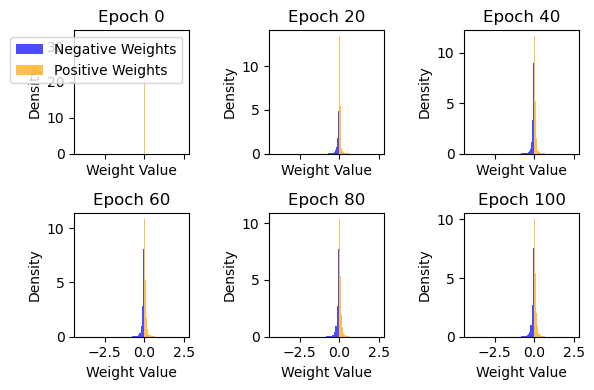

In [66]:
# for epochs 0, 20, 40, 60, 80, 100, plot histogram of positive and negative weights separately in one plot
# so 6 plot in total, in each one, blue curve for negative weights, orange curve for positive weights
epochs_to_plot = [0, 20, 40, 60, 80, 100]
fig, axes = plt.subplots(2, 3, figsize=(6,4), sharex=True)
axes = axes.flatten()

for i, epoch in enumerate(epochs_to_plot):
    if epoch == 0:
        Wr = initial_Wrtpc
    else:
        tpc_weights = load_model(tpc_path, epoch)
        Wr = tpc_weights['model']['Wr.weight'].cpu().numpy().flatten()
    pos_weights = Wr[Wr >= 0]
    neg_weights = Wr[Wr < 0]
    
    axes[i].hist(neg_weights, bins=50, density=True, alpha=0.7, color='blue', label='Negative Weights')
    axes[i].hist(pos_weights, bins=50, density=True, alpha=0.7, color='orange', label='Positive Weights')
    axes[i].set_title(f'Epoch {epoch}')
    axes[i].set_xlabel('Weight Value')
    axes[i].set_ylabel('Density')
    if i == 0:  # Only add legend to first subplot
        axes[i].legend()

plt.tight_layout()
plt.show()


In [5]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans

# 1. Normalize a curve
def normalize_curve(curve):
    min_val = np.min(curve)
    max_val = np.max(curve)
    return (curve - min_val) / (max_val - min_val + 1e-8)

# 2. Define sigmoid function
def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k*(x - x0))) + b

# 3. Fit sigmoid to curve
def fit_sigmoid(x, y):
    # Initial guess for parameters: L, x0, k, b
    p0 = [1, np.median(x), 1, 0]
    try:
        popt, _ = curve_fit(sigmoid, x, y, p0, maxfev=10000)
        return popt  # [L, x0, k, b]
    except RuntimeError:
        return None  # Fitting failed


In [6]:
def top_score_evolution(path, filter=False, **kwargs):
    scores = np.array([np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{i}.npy')) for i in range(2, 102, 2)])
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]
    scores = scores[:, idx]
    if filter:
        scores = savgol_filter(scores, axis=0, **kwargs)
    return scores

def top_size_by_scale_evolution(path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average'):
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]
    size_by_scales = np.zeros((51, n_cells))
    for i in tqdm(np.arange(0, 102, 2)):
        sac = np.load(os.path.join(path, f'sacs/sacs_epoch_{i}.npy'))
        sac = sac[idx][:n_cells]
        for c in range(n_cells):
            metrics = compute_grid_metrics(sac[c], env_size, size_thresh, scale_method)
            size = metrics['grid_size_meters']
            scale = metrics['grid_scale_meters']
            size_by_scales[i//2, c] = size / scale 
    return size_by_scales


In [7]:
def extract_popts(path, n_cells=16):
    filter_kwargs = {'window_length': 10, 'polyorder': 2}
    score_evolution = top_score_evolution(path, filter=True, **filter_kwargs)
    score_evolution = score_evolution[:, :n_cells]
    x = np.arange(2, 102, 2)
    popts = {}
    for i in range(n_cells):
        curve = score_evolution[:, i]
        popt = fit_sigmoid(x, curve)
        y_fit = sigmoid(x, *popt)
        if y_fit[0] < y_fit[-1]:
            popts[i] = popt
        else:
            popts[i] = None
    return popts

def get_clusters(popts, path, low=33, high=66):
    x = np.arange(2, 102, 2)
    score_evolution_unfiltered = top_score_evolution(path, filter=False)
    early, middle, late = [], [], []
    for i in range(len(popts)):
        if popts[i] is not None:
            inflection_point = popts[i][1]
            if inflection_point < low:
                early.append(i)
            elif inflection_point > low and inflection_point < high:
                middle.append(i)
            else:
                late.append(i)
    scores_early = score_evolution_unfiltered[:, early]
    scores_middle = score_evolution_unfiltered[:, middle]
    scores_late = score_evolution_unfiltered[:, late]
    return scores_early, scores_middle, scores_late

def plot_clusters(scores_early, scores_middle, scores_late, ax, legend=True, x_label=True, ylabel=True):
    x = np.arange(2, 102, 2)
    mean_early = np.mean(scores_early, axis=1)
    mean_middle = np.mean(scores_middle, axis=1)
    mean_late = np.mean(scores_late, axis=1)

    if np.all(np.isnan(mean_early)) and np.all(np.isnan(mean_middle)) and np.all(np.isnan(mean_late)):
        print("All means are NaN. Nothing to plot.")
        return

    if not np.all(np.isnan(mean_early)):
        early_p = fit_sigmoid(x, mean_early)
        ax.plot(x, mean_early, label='Early', color='gray', linestyle='--', lw=2)
        ax.plot(x, sigmoid(x, *early_p), color='gray', lw=2)
    if not np.all(np.isnan(mean_middle)):
        middle_p = fit_sigmoid(x, mean_middle)
        ax.plot(x, mean_middle, label='Middle', color='k', linestyle='--', lw=2)
        ax.plot(x, sigmoid(x, *middle_p), color='k', lw=2)
    if not np.all(np.isnan(mean_late)):
        late_p = fit_sigmoid(x, mean_late)
        ax.plot(x, mean_late, label='Late', color='r', linestyle='--', lw=2)
        ax.plot(x, sigmoid(x, *late_p), color='r', lw=2)

    if x_label:
        ax.set_xlabel('Epoch')
    if ylabel:
        ax.set_ylabel('Grid score')
    if legend:
        ax.legend(frameon=False, loc='upper left', fontsize=10)

def plot_cells(path, n_cells=16):
    x = np.arange(2, 102, 2)
    filter_kwargs = {'window_length': 10, 'polyorder': 2}
    score_evolution = top_score_evolution(path, filter=True, **filter_kwargs)
    score_evolution = score_evolution[:, :n_cells]
    score_evolution_unfiltered = top_score_evolution(path, filter=False)
    score_evolution_unfiltered = score_evolution_unfiltered[:, :n_cells]

    fig, axes = plt.subplots(2, 8, figsize=(16, 4), sharey=True)
    for i, ax in enumerate(axes.flatten()):
        curve = score_evolution[:, i]
        curve_unfiltered = score_evolution_unfiltered[:, i]
        popt = fit_sigmoid(x, curve)
        y_fit = sigmoid(x, *popt)
        
        ax.plot(x, curve_unfiltered, color='k')
        ax.plot(x, y_fit, color='r')
        ax.set_title(f'Cell {i}')
        if i == 0:
            ax.set_ylabel('Score')
            ax.set_xlabel('Epoch')
        plt.tight_layout()
    plt.show()
                

## Loss

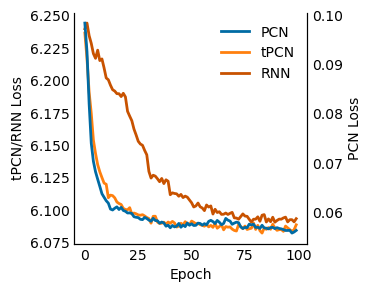

In [68]:
# pcn_loss = np.load(os.path.join(pcn_path, 'training_loss.npy'))
mpl.style.use('tableau-colorblind10')
pcn_loss = np.load(os.path.join(pcn_path, 'training_loss.npy'))
tpc_loss = np.load(os.path.join(tpc_path, 'loss.npy'))
rnn_loss = np.load(os.path.join(rnn_path, 'loss.npy'))
tbptt_loss = np.load(os.path.join(tbptt_path, 'loss.npy'))

line_width = 2  # Set line width as a parameter

fig, ax = plt.subplots(figsize=(3,3))
ax.plot([], label='PCN', color='C0', lw=line_width)
ax.plot(tpc_loss, label='tPCN', color='C1', lw=line_width)
ax.plot(rnn_loss, label='RNN', color='C5', lw=line_width)
ax.set_ylabel('tPCN/RNN Loss')
ax2 = plt.twinx(ax=ax)
ax2.plot(pcn_loss, label='PCN', color='C0', lw=line_width)
ax2.set_ylabel('PCN Loss')

ax.legend(fontsize=10, frameon=False)
# ax2.legend(fontsize=10, frameon=False, loc='upper right')
# plt.plot(tbptt_loss, label='tBPTT', color='C3', lw=2)
# plt.tight_layout()
ax.set_xlabel('Epoch')
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='both', length=0, labelsize=10)
ax2.tick_params(axis='both', which='both', length=0, labelsize=10)
# plt.tight_layout()
plt.savefig('../results/learning/loss.pdf', bbox_inches='tight')
plt.show()


## Size/scales

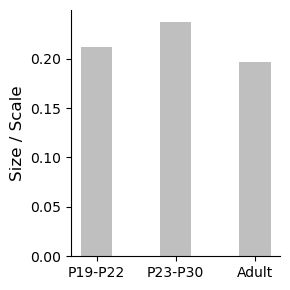

In [80]:
# from rats
rats_data = np.array([
    # 22.406433840223606,
    21.21850435414375,
    23.745219523516408,
    19.645866338382053
])
xlabels = [
    'P19-P22',
    'P23-P30',
    'Adult',
]
rats_data = rats_data/100.0  # convert to size/scale

plt.figure(figsize=(3,3))
plt.bar(np.arange(len(rats_data)), rats_data, color='gray', alpha=0.5, label='Rats', width=0.4)
# overlap with line
# plt.plot(np.arange(len(rats_data)), rats_data, color='k', lw=2)
plt.ylabel('Size / Scale', fontsize=12)
plt.xticks(np.arange(len(rats_data)), xlabels)
# remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/learning/rats_size_by_scale.pdf', bbox_inches='tight')


In [9]:
def select_starting_epoch(path, n_cells=16, quatile=0.75):
    score_evo = top_score_evolution(path)
    score_top_avg_evo = score_evo[:, :n_cells].mean(axis=1)
    # select epoch where the average score is above 75% quantile
    thresh_epoch = np.quantile(score_top_avg_evo, quatile)
    selected_epoch = np.where(score_top_avg_evo > thresh_epoch)[0][0]
    return selected_epoch

In [10]:
def plot_size_by_scale(size_by_scale):
    fig, axes = plt.subplots(2, 8, figsize=(16, 4), sharey=True)
    for i, ax in enumerate(axes.flatten()):
        curve = size_by_scale[:, i]
        ax.plot(np.arange(0, 102, 2), curve, color='k')
        ax.set_title(f'Cell {i}')
        if i == 0:
            ax.set_ylabel('Size / Scale')
            ax.set_xlabel('Epoch')
    plt.tight_layout()

In [11]:
pcn_size_by_scale = top_size_by_scale_evolution(pcn_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
pcn_starting_epoch = select_starting_epoch(pcn_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:04<00:00, 12.64it/s]


In [12]:
tpc_size_by_scale = top_size_by_scale_evolution(tpc_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
tpc_starting_epoch = select_starting_epoch(tpc_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:01<00:00, 27.13it/s]


In [13]:
tpc_sparse_size_by_scale = top_size_by_scale_evolution(tpc_sparse_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
tpc_sparse_starting_epoch = select_starting_epoch(tpc_sparse_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:01<00:00, 26.80it/s]


In [14]:
rnn_size_by_scale = top_size_by_scale_evolution(rnn_path, n_cells=16, env_size=1.6, size_thresh=0.5, scale_method='average')
rnn_starting_epoch = select_starting_epoch(rnn_path, n_cells=16, quatile=0.75)

100%|██████████| 51/51 [00:02<00:00, 22.35it/s]


In [15]:
print(f'PCN starting epoch: {pcn_starting_epoch}')
print(f'tPCN starting epoch: {tpc_starting_epoch}')
print(f'stPCN starting epoch: {tpc_sparse_starting_epoch}')
print(f'RNN starting epoch: {rnn_starting_epoch}')

# pcn_size_by_scale = pcn_size_by_scale[pcn_starting_epoch:]
# tpc_size_by_scale = tpc_size_by_scale[tpc_starting_epoch:]
# tpc_sparse_size_by_scale = tpc_sparse_size_by_scale[tpc_sparse_starting_epoch:]
# rnn_size_by_scale = rnn_size_by_scale[rnn_starting_epoch:]

PCN starting epoch: 31
tPCN starting epoch: 23
stPCN starting epoch: 37
RNN starting epoch: 37


In [16]:
for i in range(16):
    if any(rnn_size_by_scale[:, i] > 10):
        print(f'Cell {i} in RNN has size/scale > 10')

Cell 15 in RNN has size/scale > 10


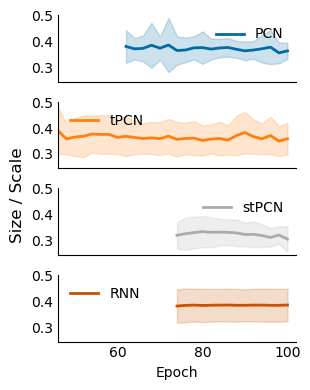

In [15]:
fig, ax = plt.subplots(4, 1, figsize=(3, 4), sharex=True, sharey=True)
ax[0].plot(np.arange(2*pcn_starting_epoch, 102, 2), pcn_size_by_scale.mean(axis=1), label='PCN', color='C0', lw=2)
ax[0].fill_between(
    np.arange(2*pcn_starting_epoch, 102, 2), pcn_size_by_scale.mean(axis=1) - pcn_size_by_scale.std(axis=1),
    pcn_size_by_scale.mean(axis=1) + pcn_size_by_scale.std(axis=1), alpha=0.2, color='C0'
)
ax[1].plot(np.arange(2*tpc_starting_epoch, 102, 2), tpc_size_by_scale.mean(axis=1), label='tPCN', color='C1', lw=2)
ax[1].fill_between(
    np.arange(2*tpc_starting_epoch, 102, 2), tpc_size_by_scale.mean(axis=1) - tpc_size_by_scale.std(axis=1),
    tpc_size_by_scale.mean(axis=1) + tpc_size_by_scale.std(axis=1), alpha=0.2, color='C1'
)
ax[2].plot(np.arange(2*tpc_sparse_starting_epoch, 102, 2), tpc_sparse_size_by_scale.mean(axis=1), label='stPCN', color='C2', lw=2)
ax[2].fill_between(
    np.arange(2*tpc_sparse_starting_epoch, 102, 2), tpc_sparse_size_by_scale.mean(axis=1) - tpc_sparse_size_by_scale.std(axis=1),
    tpc_sparse_size_by_scale.mean(axis=1) + tpc_sparse_size_by_scale.std(axis=1), alpha=0.2, color='C2'
)
ax[3].plot(np.arange(2*rnn_starting_epoch, 102, 2), rnn_size_by_scale.mean(axis=1), label='RNN', color='C5', lw=2)
ax[3].fill_between(
    np.arange(2*rnn_starting_epoch, 102, 2), rnn_size_by_scale.mean(axis=1) - rnn_size_by_scale.std(axis=1),
    rnn_size_by_scale.mean(axis=1) + rnn_size_by_scale.std(axis=1), alpha=0.2, color='C5'
)
ax[3].set_xlabel('Epoch')
# ax[0].set_ylabel('Size / Scale')
# set a sup ylabel for all subplots
fig.text(-0.02, 0.5, 'Size / Scale', va='center', rotation='vertical', fontsize=12)
for a in ax:
    a.legend(frameon=False, fontsize=10)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', which='both', length=0, labelsize=10)
    # make all x ticks start from the mininum of the starting epochs
    start = min(pcn_starting_epoch, tpc_starting_epoch, tpc_sparse_starting_epoch, rnn_starting_epoch)
    a.set_xlim(2*start, 102)
plt.tight_layout()
plt.savefig('../results/abrupt/size_by_scale.pdf', bbox_inches='tight')

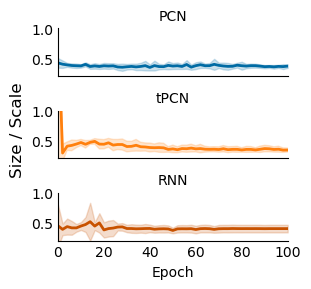

In [108]:
# similar to the previous cell, find the mean and std of the size by scale of first 8 cells
# start from the first epoch where the average size by scale of first 8 cells is below 0.5
start_epoch = 0
x = np.arange(2 * start_epoch, 102, 2)
num_cells = 12
fig, ax = plt.subplots(3, 1, figsize=(3, 3), sharex=True, sharey=True)
ax[0].plot(x, pcn_size_by_scale[start_epoch:,:num_cells].mean(axis=1), color='C0', lw=2)
ax[0].fill_between(
    x, 
    pcn_size_by_scale[start_epoch:,:num_cells].mean(axis=1) - pcn_size_by_scale[start_epoch:,:num_cells].std(axis=1), 
    pcn_size_by_scale[start_epoch:,:num_cells].mean(axis=1) + pcn_size_by_scale[start_epoch:,:num_cells].std(axis=1), 
    alpha=0.2, color='C0'
)
ax[0].set_title('PCN', fontsize=10)

ax[1].plot(x, tpc_size_by_scale[start_epoch:,:num_cells].mean(axis=1), color='C1', lw=2)
ax[1].fill_between(
    x, 
    tpc_size_by_scale[start_epoch:,:num_cells].mean(axis=1) - tpc_size_by_scale[start_epoch:,:num_cells].std(axis=1), 
    tpc_size_by_scale[start_epoch:,:num_cells].mean(axis=1) + tpc_size_by_scale[start_epoch:,:num_cells].std(axis=1), 
    alpha=0.2, color='C1'
)
ax[1].set_title('tPCN', fontsize=10)

ax[2].plot(x, rnn_size_by_scale[start_epoch:,:num_cells].mean(axis=1), color='C5', lw=2)
ax[2].fill_between(
    x, 
    rnn_size_by_scale[start_epoch:,:num_cells].mean(axis=1) - rnn_size_by_scale[start_epoch:,:num_cells].std(axis=1), 
    rnn_size_by_scale[start_epoch:,:num_cells].mean(axis=1) + rnn_size_by_scale[start_epoch:,:num_cells].std(axis=1), 
    alpha=0.2, color='C5'
)
ax[2].set_title('RNN', fontsize=10)

ax[2].set_xlabel('Epoch')
# limit the yaxis to 0.5
ax[0].set_ylim(0.2, 1.0)
ax[1].set_ylim(0.2, 1.0)
ax[2].set_ylim(0.2, 1.0)
# set x ticks to start from start_epoch, and end at 100
for a in ax:
    a.set_xlim(start_epoch, 100)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', which='both', length=0, labelsize=10)
# add y label to be size by scale
fig.text(-0.02, 0.55, 'Size / Scale', va='center', rotation='vertical', fontsize=12)
plt.tight_layout()
plt.savefig('../results/learning/size_by_scale.pdf', bbox_inches='tight')


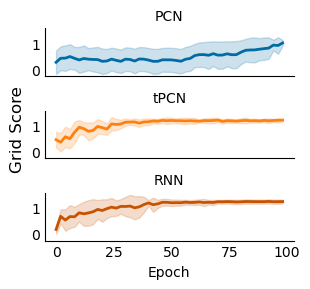

In [64]:
# plot similar figure, with top score evolution of first num_cells cells, no filtering
starting_epoch = 0
num_cells = 12

fig, ax = plt.subplots(3, 1, figsize=(3, 3), sharex=True, sharey=True)
x = np.arange(2 * starting_epoch, 100, 2)

ax[0].plot(x, top_score_evolution(pcn_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1), color='C0', lw=2)
ax[0].fill_between(
    x, 
    top_score_evolution(pcn_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1) - top_score_evolution(pcn_path, filter=False)[starting_epoch:, :num_cells].std(axis=1), 
    top_score_evolution(pcn_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1) + top_score_evolution(pcn_path, filter=False)[starting_epoch:, :num_cells].std(axis=1), 
    alpha=0.2, color='C0'
)
ax[0].set_title('PCN', fontsize=10)

ax[1].plot(x, top_score_evolution(tpc_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1), color='C1', lw=2)
ax[1].fill_between(
    x, 
    top_score_evolution(tpc_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1) - top_score_evolution(tpc_path, filter=False)[starting_epoch:, :num_cells].std(axis=1), 
    top_score_evolution(tpc_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1) + top_score_evolution(tpc_path, filter=False)[starting_epoch:, :num_cells].std(axis=1), 
    alpha=0.2, color='C1'
)
ax[1].set_title('tPCN', fontsize=10)

ax[2].plot(x, top_score_evolution(rnn_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1), color='C5', lw=2)
ax[2].fill_between(
    x, 
    top_score_evolution(rnn_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1) - top_score_evolution(rnn_path, filter=False)[starting_epoch:, :num_cells].std(axis=1), 
    top_score_evolution(rnn_path, filter=False)[starting_epoch:, :num_cells].mean(axis=1) + top_score_evolution(rnn_path, filter=False)[starting_epoch:, :num_cells].std(axis=1), 
    alpha=0.2, color='C5'
)
ax[2].set_title('RNN', fontsize=10)

ax[2].set_xlabel('Epoch')
# set a sup ylabel for all subplots
fig.text(-0.02, 0.55, 'Grid Score', va='center', rotation='vertical', fontsize=12)
for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(axis='both', which='both', length=0, labelsize=10)
plt.tight_layout()
plt.savefig('../results/learning/score.pdf', bbox_inches='tight')

## Call examples

In [16]:
def get_epoch_rms(path, cell_indices):
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]

    all_rms = []
    all_scores = []
    for epoch in [0, 34, 66, 100]:
        rms = np.load(os.path.join(path, f'rate_maps_epoch/rate_map_epoch_{epoch}.npy'))
        scores = np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{epoch}.npy'))
        rms = rms[idx]
        rms = rms[cell_indices]
        scores = scores[idx]
        scores = scores[cell_indices]
        all_rms.append(rms)
        all_scores.append(scores)
    all_rms = np.array(all_rms)
    all_scores = np.array(all_scores)

    return all_rms, all_scores

def get_individual_scores(path, cell_indices):
    final_scores = np.load(os.path.join(path, 'grid_scores/grid_scores_epoch_100.npy'))
    idx = np.argsort(final_scores)[::-1]

    scores = [np.load(os.path.join(path, f'grid_scores/grid_scores_epoch_{e}.npy')) for e in range(0, 102, 2)]
    scores = np.array(scores)
    scores = scores[:, idx]
    scores = scores[:, cell_indices]

    return scores

(4, 2, 30, 30)


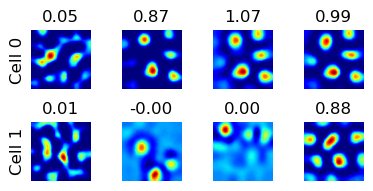

In [17]:
pcn_cells = [6, 10]
pcn_rms, pcn_scores = get_epoch_rms(pcn_path, np.array(pcn_cells))
print(pcn_rms.shape)
fig, ax = plt.subplots(len(pcn_cells), 4, figsize=(4, 2))
for i in range(len(pcn_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(pcn_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{pcn_scores[j, i]:.2f}')

plt.tight_layout()
plt.savefig('../results/abrupt/pcn_rm.pdf', bbox_inches='tight')
plt.show()


(4, 2, 20, 20)


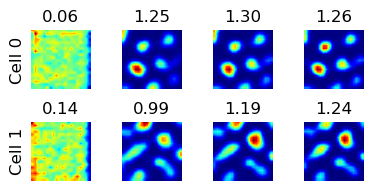

In [18]:
tpc_cells = [0, 1]
tpc_rms, tpc_scores = get_epoch_rms(tpc_path, np.array(tpc_cells))
print(tpc_rms.shape)
fig, ax = plt.subplots(len(tpc_cells), 4, figsize=(4, 2))
for i in range(len(tpc_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(tpc_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{tpc_scores[j, i]:.2f}')

plt.tight_layout()
plt.savefig('../results/abrupt/tpc_rm.pdf', bbox_inches='tight')
plt.show()

(4, 2, 20, 20)


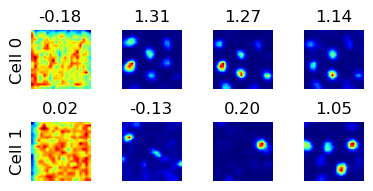

In [19]:
tpc_sparse_cells = [3, 9]
tpc_sparse_rms, tpc_sparse_scores = get_epoch_rms(tpc_sparse_path, np.array(tpc_sparse_cells))
print(tpc_sparse_rms.shape)
fig, ax = plt.subplots(len(tpc_sparse_cells), 4, figsize=(4, 2))
for i in range(len(tpc_sparse_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(tpc_sparse_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{tpc_sparse_scores[j, i]:.2f}')

plt.tight_layout()
plt.savefig('../results/abrupt/tpc_sparse_rm.pdf', bbox_inches='tight')
plt.show()

(4, 2, 20, 20)


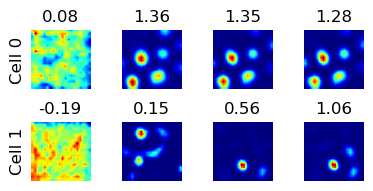

In [30]:
rnn_cells = [3, 15]
rnn_rms, rnn_scores = get_epoch_rms(rnn_path, np.array(rnn_cells))
print(rnn_rms.shape)
fig, ax = plt.subplots(len(rnn_cells), 4, figsize=(4, 2))
for i in range(len(rnn_cells)):
    ax[i, 0].set_ylabel(f'Cell {i}', fontsize=12)
    for j in range(4):
        ax[i, j].imshow(rnn_rms[j, i], cmap='jet', interpolation='bilinear')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        # remove borders
        ax[i, j].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
        ax[i, j].set_title(f'{rnn_scores[j, i]:.2f}')
plt.tight_layout()
plt.savefig('../results/abrupt/rnn_rm.pdf', bbox_inches='tight')
plt.show()

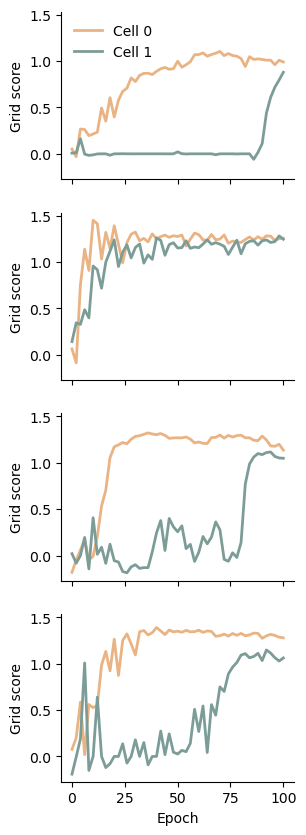

In [32]:
pcn_scores = get_individual_scores(pcn_path, np.array(pcn_cells))
tpc_scores = get_individual_scores(tpc_path, np.array(tpc_cells))
tpc_sparse_scores = get_individual_scores(tpc_sparse_path, np.array(tpc_sparse_cells))
rnn_scores = get_individual_scores(rnn_path, np.array(rnn_cells))

fig, ax = plt.subplots(4, 1, figsize=(3, 10), sharex=True, sharey=True)
# remove top and right spines
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].plot(np.arange(0, 102, 2), pcn_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[0].plot(np.arange(0, 102, 2), pcn_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[0].set_ylabel('Grid score')
ax[0].legend(frameon=False)
ax[0].set_yticks([0, 0.5, 1, 1.5])

ax[1].spines[['top', 'right']].set_visible(False)
ax[1].plot(np.arange(0, 102, 2), tpc_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[1].plot(np.arange(0, 102, 2), tpc_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[1].set_ylabel('Grid score')
# ax[1].legend(frameon=False)

ax[2].spines[['top', 'right']].set_visible(False)
ax[2].plot(np.arange(0, 102, 2), tpc_sparse_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[2].plot(np.arange(0, 102, 2), tpc_sparse_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[2].set_ylabel('Grid score')
# ax[2].legend(frameon=False)

ax[3].spines[['top', 'right']].set_visible(False)
ax[3].plot(np.arange(0, 102, 2), rnn_scores[:, 0], label='Cell 0', color="#e9b383", lw=2)
ax[3].plot(np.arange(0, 102, 2), rnn_scores[:, 1], label='Cell 1', color="#7c9d97", lw=2)
ax[3].set_xlabel('Epoch')
ax[3].set_ylabel('Grid score')
# ax[3].legend(frameon=False)

# plt.tight_layout()
plt.savefig('../results/abrupt/individual.pdf', bbox_inches='tight')
plt.show()


## Scores

C:\Users\User\AppData\Local\Temp\ipykernel_1968\2519742339.py:13: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k*(x - x0))) + b


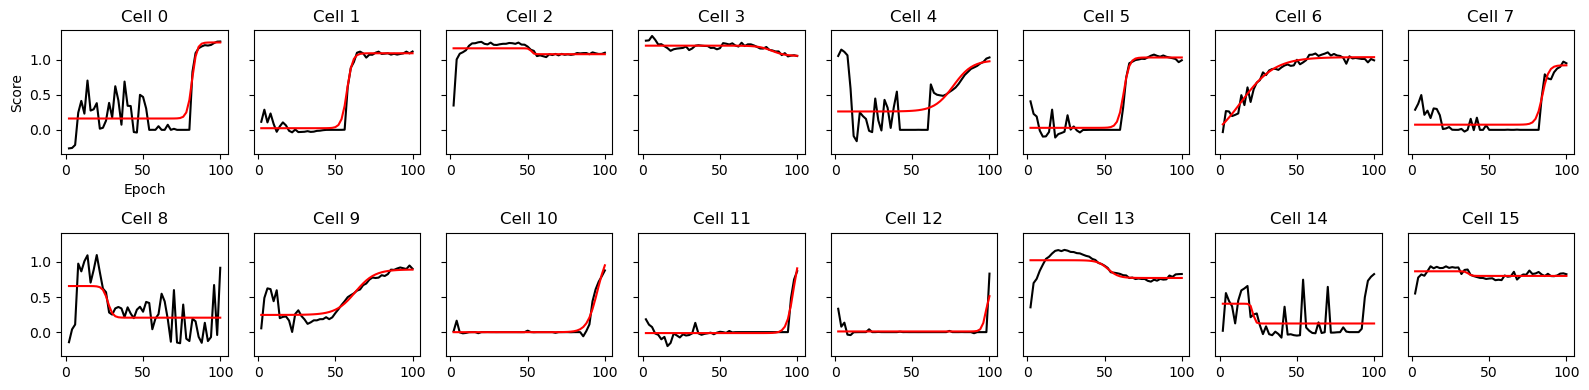

In [22]:
pcn_popts = extract_popts(pcn_path, n_cells=16)
plot_cells(pcn_path, n_cells=16)

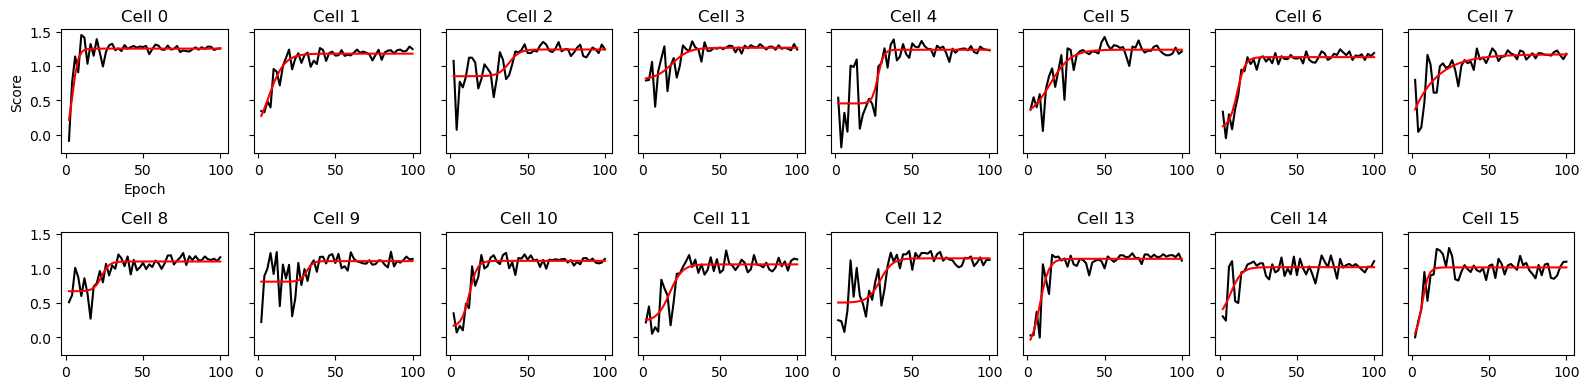

In [103]:
tpc_popts = extract_popts(tpc_path, n_cells=32)
plot_cells(tpc_path, n_cells=32)

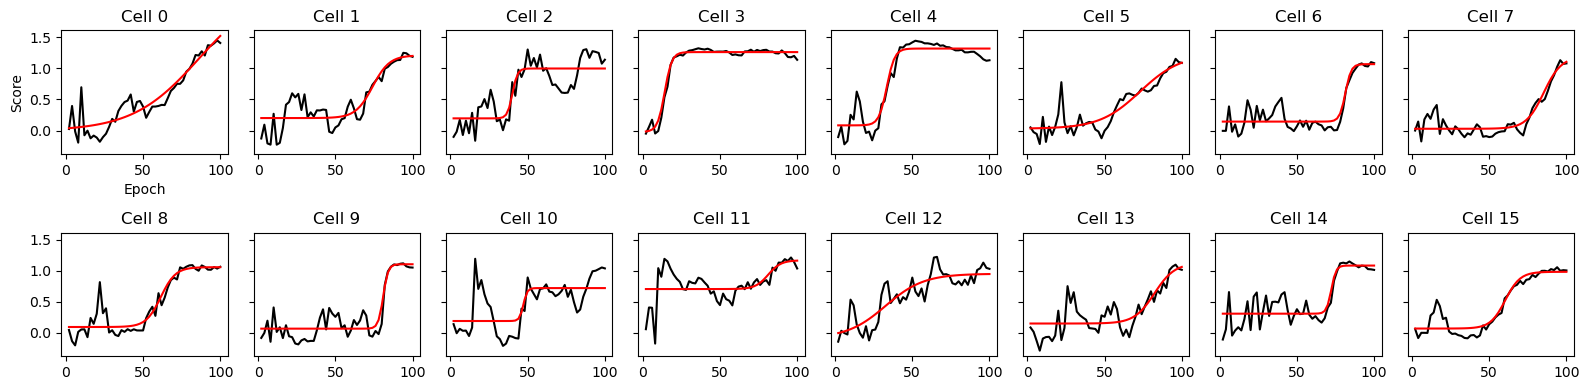

In [24]:
tpc_sparse_popts = extract_popts(tpc_sparse_path, n_cells=16)
plot_cells(tpc_sparse_path, n_cells=16)

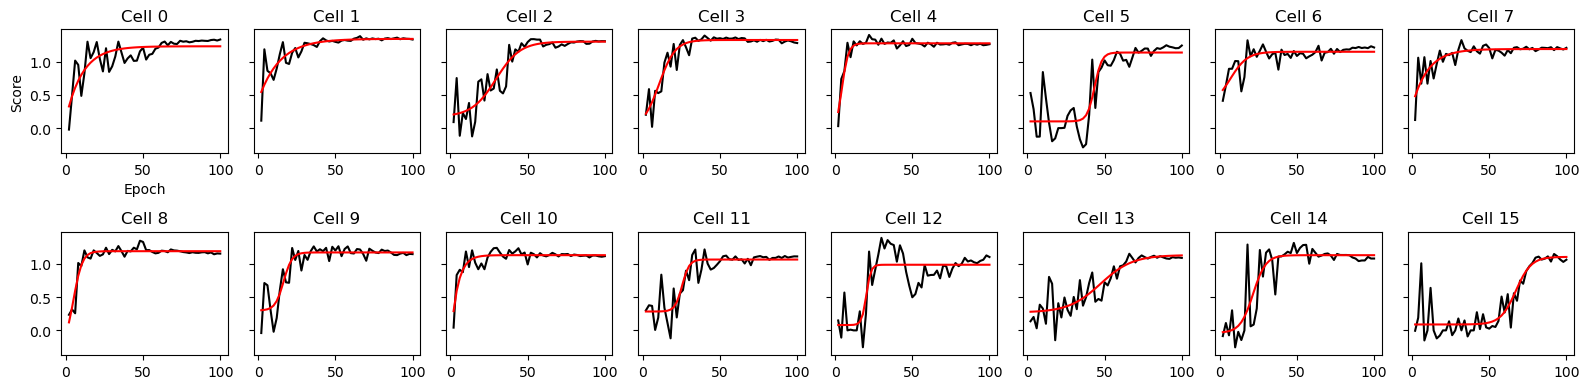

In [101]:
rnn_popts = extract_popts(rnn_path, n_cells=32)
plot_cells(rnn_path, n_cells=32)

In [104]:
# get the average epoch at which the fitted curve reaches maximum for tpc and rnn
# by first finding the first epoch where the score is equal to or greater than 95% of the maximum score
def get_average_max_epoch(popts):
    max_epochs = []
    for i in range(len(popts)):
        if popts[i] is not None:
            y_fit = sigmoid(np.arange(2, 102, 2), *popts[i])
            max_score = np.max(y_fit)
            thresh_score = 0.95 * max_score
            # find the first epoch where the score is equal to or greater than thresh_score
            for epoch, fit_score in zip(np.arange(2, 102, 2), y_fit):
                if fit_score >= thresh_score:
                    max_epochs.append(epoch)
                    break
    return max_epochs

tpc_max_epochs = get_average_max_epoch(tpc_popts)
rnn_max_epochs = get_average_max_epoch(rnn_popts)

np.mean(tpc_max_epochs), np.std(tpc_max_epochs)

(28.64516129032258, 14.209375340057376)

In [105]:
np.mean(rnn_max_epochs), np.std(rnn_max_epochs)

(41.1875, 22.202811618126205)

In [109]:
from scipy.stats import mannwhitneyu
u_stat, p_value = mannwhitneyu(tpc_max_epochs, rnn_max_epochs, alternative='less')

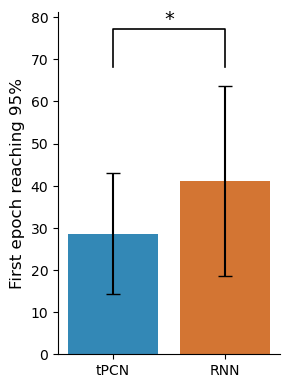

Mann–Whitney U = 337.00, p = 0.015


In [116]:
# Compute mean and std
means = [np.mean(tpc_max_epochs), np.mean(rnn_max_epochs)]
stds = [np.std(tpc_max_epochs, ddof=1), np.std(rnn_max_epochs, ddof=1)]

# Bar plot
labels = ['tPCN', 'RNN']
colors = ['C0', 'C5']

fig, ax = plt.subplots(figsize=(3, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors, alpha=0.8)

# Add significance asterisk(s)
# Define a helper function for placing asterisks
def significance_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'  # not significant

sig_label = significance_star(p_value)

# Coordinates for annotation
x1, x2 = 0, 1
y, h = max(means) + max(stds)*1.2, max(stds)*0.4
ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='black')
ax.text((x1 + x2) * 0.5, y + h, sig_label, ha='center', va='bottom', fontsize=14)

# Styling
ax.set_ylabel('First epoch reaching 95%', fontsize=12)
# ax.set_title('Comparison of 95%-reach epochs')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/learning/epoch_95.pdf', bbox_inches='tight')
plt.show()

print(f"Mann–Whitney U = {u_stat:.2f}, p = {p_value:.3f}")

## Clusters

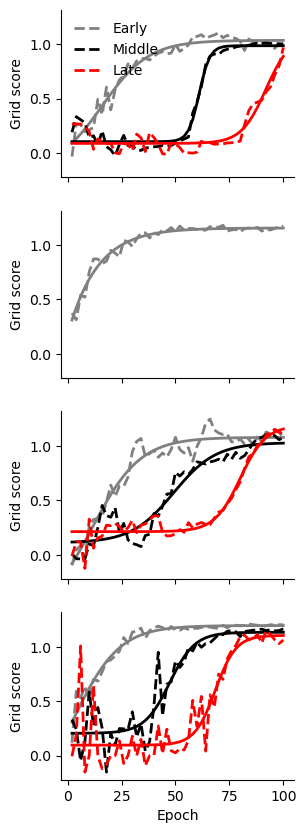

In [27]:
fig, ax = plt.subplots(4, 1, figsize=(3, 10), sharex=True, sharey=True)
for a in ax:
    a.spines[['top', 'right']].set_visible(False)
plot_clusters(*get_clusters(pcn_popts, pcn_path), ax=ax[0], legend=True, x_label=False, ylabel=True)
plot_clusters(*get_clusters(tpc_popts, tpc_path, low=40, high=66), ax=ax[1], legend=False, x_label=False, ylabel=True)
plot_clusters(*get_clusters(tpc_sparse_popts, tpc_sparse_path), ax=ax[2], legend=False, x_label=False, ylabel=True)
plot_clusters(*get_clusters(rnn_popts, rnn_path), ax=ax[3], legend=False, x_label=True, ylabel=True)
plt.savefig('../results/abrupt/clusters.pdf', bbox_inches='tight')
plt.show()